<div style="background: linear-gradient(135deg, #16324F 0%, #2F6690 100%); padding: 34px; border-radius: 16px; color: white; text-align: center; margin-bottom: 18px;">
  <h1 style="margin: 0 0 8px 0; font-size: 2.15em;">NSC 2026 — AIR HUMIDITY PREDICTION</h1>
  <h2 style="margin: 0 0 14px 0; font-size: 1.3em; font-weight: 500;">FINALIZATION IPYNB — TEAM HBD</h2>
  <hr style="border: 1px solid rgba(255,255,255,0.35); margin: 14px 60px;">
  <p style="margin: 0; font-size: 1.02em;">Prediksi <strong>air_humidity</strong> · Validasi <strong>RMSE</strong> · Deret waktu multivariat</p>
</div>

| Komponen | Keterangan |
|---|---|
| **Target** | `air_humidity` |
| **Kunci waktu** | `datetime` |
| **Input runtime** | `train.csv`, `test.csv`, `sample_submission.csv` |
| **Keluaran** | `FINALIZATION_submission.csv` dan artefak model `.pth` |
| **Prinsip** | EDA-driven, validasi temporal, tanpa data eksternal |

> **Pernyataan integritas:** notebook ini dirancang hanya membaca tiga input resmi saat runtime. Tidak ada ground truth test, reference CSV, submission lama, internet, API, atau dataset eksternal yang digunakan.


# 01. Tujuan dan Latar Belakang

---

Kompetisi meminta prediksi `air_humidity` untuk periode uji berikutnya dengan metrik resmi **RMSE**. Data berbentuk observasi sensor berurutan menurut `datetime` dan dicatat pada interval 30 menit. Pada `test.csv`, sensor eksogen tetap tersedia sementara target `air_humidity` tidak tersedia.

Karena itu, permasalahan diperlakukan sebagai **regresi deret waktu multivariat dengan sensor eksogen konkuren**. Fokus notebook bukan membuat resep baru, melainkan mendokumentasikan dan memfinalisasi resep model yang sudah dipilih sebelumnya secara transparan, runnable, dan dapat diaudit.


## Alur Pipeline Notebook

```text
train/test/sample
      │
      ▼
[01] Audit input & integritas
      │
      ▼
[02] EDA mendalam
      │
      ▼
[03] Temuan EDA → keputusan teknis
      │
      ├──────────────┐
      ▼              ▼
[04] Tahap 1      [05] Tahap 2
Daily level      Intraday deviation
      │              │
      └───────┬──────┘
              ▼
[06] Rekonstruksi + smoothing
              │
              ▼
[07] Post-modelling dibekukan recipe
              │
              ▼
[08] Final prediksi → QA → artefak `.pth`
```

Struktur ini mengikuti pola notebook referensi yang kuat: **judul → alur → bagian → metodologi → kode → output → interpretasi**, tetapi seluruh isi dan recipe model tetap berasal dari notebook HBD.


# 02. Environment dan Reproducibility

---

### Metodologi

Environment diatur sebelum proses berat dijalankan. Seed, jumlah thread, dan pengaturan deterministik dipertahankan sesuai recipe sumber. Tidak ada perubahan seed atau hyperparameter inti yang dilakukan demi memperbaiki skor.


In [1]:
import os
for v in [
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "NUMEXPR_NUM_THREADS"
]:
    os.environ[v] = "1"

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["PYTHONHASHSEED"] = "0"

import random
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import torch
import torch.nn as nn
torch.manual_seed(SEED)
torch.set_num_threads(1)

try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 200)

print("Seed:", SEED)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)
print("xgboost:", xgb.__version__)
print("lightgbm:", lgb.__version__)
print("Pengaturan seed dan deterministik selesai.")


Seed: 42
numpy: 1.26.4
pandas: 2.2.1
torch: 2.2.1+cpu
xgboost: 3.2.0
lightgbm: 4.6.0
Pengaturan seed dan deterministik selesai.


### Interpretasi

Cell ini hanya menyiapkan lingkungan. Nilai `SEED` menjadi acuan seluruh proses acak pada ensemble. Tidak ada data yang dibaca dari sumber eksternal pada tahap ini.


# 03. Input Resmi dan Audit Integritas Data

---

### Metodologi

Notebook final hanya memuat tiga input runtime. Path dibuat relatif agar notebook tidak bergantung pada komputer tertentu. Audit mencakup keberadaan file, schema, target, urutan waktu, timestamp duplikat, kontinuitas interval, missing timestamp, dan kecocokan `sample_submission` terhadap `test`.


In [2]:
from pathlib import Path

TRAIN_PATH = Path("train.csv")
TEST_PATH = Path("test.csv")
SAMPLE_PATH = Path("sample_submission.csv")

for p in [TRAIN_PATH, TEST_PATH, SAMPLE_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"File input tidak ditemukan: {p}")

TARGET = "air_humidity"
KEY = "datetime"

train = (
    pd.read_csv(TRAIN_PATH, parse_dates=[KEY])
      .sort_values(KEY)
      .reset_index(drop=True)
)

test = (
    pd.read_csv(TEST_PATH, parse_dates=[KEY])
      .sort_values(KEY)
      .reset_index(drop=True)
)

# Jumlah observasi train dipakai sebagai batas indeks train/test setelah konkatenasi.
N = len(train)

samp = pd.read_csv(SAMPLE_PATH)

# Validasi schema inti.
assert TARGET in train.columns, "Kolom target air_humidity tidak ada pada train.csv."
assert TARGET not in test.columns, "test.csv tidak boleh menyediakan target air_humidity."
assert KEY in train.columns and KEY in test.columns, "Kolom datetime wajib tersedia."
assert list(samp.columns) == [KEY, TARGET], "Schema sample_submission tidak sesuai."

# Validasi tipe, target, dan urutan waktu.
assert pd.api.types.is_datetime64_any_dtype(train[KEY])
assert pd.api.types.is_datetime64_any_dtype(test[KEY])
assert pd.api.types.is_numeric_dtype(train[TARGET])
assert train[TARGET].notna().all(), "Target train mengandung missing value."
assert train[KEY].notna().all() and test[KEY].notna().all()

# sample_submission harus persis sejajar dengan test.
sample_dt = pd.to_datetime(samp[KEY], errors="coerce")
assert sample_dt.notna().all(), "Datetime pada sample_submission mengandung nilai invalid."
assert sample_dt.reset_index(drop=True).equals(test[KEY].reset_index(drop=True))

# Audit duplicate timestamp.
assert train[KEY].duplicated().sum() == 0, "Duplicate datetime ditemukan pada train.csv."
assert test[KEY].duplicated().sum() == 0, "Duplicate datetime ditemukan pada test.csv."

# Audit kontinuitas interval 30 menit. Gap tidak diubah; hanya dicatat.
EXPECTED_STEP = pd.Timedelta(minutes=30)

def audit_timestamps(series):
    gap = series.sort_values().diff().dropna()
    gap_nonstandard = gap[gap != EXPECTED_STEP]
    missing_between = int(
        np.maximum(
            np.floor(gap_nonstandard / EXPECTED_STEP).astype(int) - 1,
            0
        ).sum()
    ) if len(gap_nonstandard) else 0
    return gap, gap_nonstandard, missing_between

train_gap, train_nonstandard, train_missing_ts = audit_timestamps(train[KEY])
test_gap, test_nonstandard, test_missing_ts = audit_timestamps(test[KEY])

print("Input runtime:")
print(" -", TRAIN_PATH)
print(" -", TEST_PATH)
print(" -", SAMPLE_PATH)
print("Shape train / test / sample:", train.shape, test.shape, samp.shape)
print("Kolom target train:", TARGET in train.columns)
print("Target pada test:", TARGET in test.columns)
print("Duplicate datetime train / test:", int(train[KEY].duplicated().sum()), "/", int(test[KEY].duplicated().sum()))
print("Gap non-30-menit train / test:", len(train_nonstandard), "/", len(test_nonstandard))
print("Perkiraan timestamp yang hilang di tengah gap train / test:", train_missing_ts, "/", test_missing_ts)
print("Rentang train:", train[KEY].min(), "→", train[KEY].max())
print("Rentang test :", test[KEY].min(), "→", test[KEY].max())
print("Kecocokan datetime sample dengan test: PASS")


Input runtime:
 - train.csv
 - test.csv
 - sample_submission.csv
Shape train / test / sample: (2933, 26) (734, 25) (734, 2)
Kolom target train: True
Target pada test: False
Duplicate datetime train / test: 0 / 0
Gap non-30-menit train / test: 1 / 0
Perkiraan timestamp yang hilang di tengah gap train / test: 13 / 0
Rentang train: 2023-06-29 06:00:00 → 2023-08-29 14:30:00
Rentang test : 2023-08-29 15:00:00 → 2023-09-13 21:30:00
Kecocokan datetime sample dengan test: PASS


### Interpretasi

Audit ini memastikan notebook tidak bergantung pada urutan kernel sebelumnya dan tidak mengasumsikan adanya file lain. Gap waktu yang ditemukan dicatat sebagai kondisi data, bukan diisi secara artifisial, agar perilaku recipe model tidak berubah.


# 04. EDA — Struktur dan Kualitas Data

---

## A. Bentuk data dan tipe kolom

### Mengapa analisis ini dilakukan

Struktur kolom menentukan informasi apa yang sah tersedia saat training dan inference. Pemeriksaan ini juga memastikan `air_humidity` hanya berada pada train dan sensor eksogen yang dipakai model tersedia pada kedua periode.


In [3]:
print("Dimensi train:", train.shape)
print("Dimensi test :", test.shape)

dtype_table = train.dtypes.rename("dtype").to_frame()
display(dtype_table)

print("Kolom hanya di train:")
print(sorted(set(train.columns) - set(test.columns)))
print("Kolom hanya di test:")
print(sorted(set(test.columns) - set(train.columns)))

print("Jumlah nilai unik per kolom penting:")
unique_audit = train[[c for c in [KEY, TARGET, "env_id"] if c in train.columns]].nunique().rename("nunique").to_frame()
display(unique_audit)


Dimensi train: (2933, 26)
Dimensi test : (734, 25)


,dtype
datetime,datetime64[ns]
env_id,float64
co2,float64
air_humidity,float64
pressure,float64
air_temperature,float64
env_battery,float64
soil_ec_line1,float64
soil_humidity_line1,float64
soil_temp_line1,float64


Kolom hanya di train:
['air_humidity']
Kolom hanya di test:
[]
Jumlah nilai unik per kolom penting:


,nunique
datetime,2933
air_humidity,2366
env_id,2933


### Interpretasi

Perbedaan schema train–test harus konsisten dengan skenario prediksi: target ada di train dan tidak ada di test. `env_id` diaudit tersendiri karena bentuk numeriknya tidak otomatis membuatnya menjadi fitur prediktif.


## B. Missing value dan duplikasi

### Mengapa analisis ini dilakukan

Missingness memengaruhi kebutuhan imputasi dan stabilitas feature engineering. Duplikasi timestamp berisiko membuat satu titik waktu memiliki lebih dari satu observasi.


In [4]:
miss_train = train.isna().sum().sort_values(ascending=False).rename("missing_train")
miss_test = test.isna().sum().sort_values(ascending=False).rename("missing_test")

missing_table = pd.concat([miss_train, miss_test], axis=1).fillna(0)
missing_table["persen_train"] = 100 * missing_table["missing_train"] / len(train)
missing_table["persen_test"] = 100 * missing_table["missing_test"] / len(test)
display(missing_table.sort_values("missing_train", ascending=False))

print("Duplicate datetime train:", int(train[KEY].duplicated().sum()))
print("Duplicate datetime test :", int(test[KEY].duplicated().sum()))


,missing_train,missing_test,persen_train,persen_test
env_battery,2873,719.0,97.954313,97.956403
soil_ec_line3,316,81.0,10.773952,11.035422
air_temperature,306,72.0,10.433004,9.809264
ontario_units,305,110.0,10.398909,14.986376
daily_max_above_Tbase,303,128.0,10.330719,17.438692
soil_humidity_line1,301,82.0,10.262530,11.171662
soil_temp_line3,299,72.0,10.194340,9.809264
gdd,298,114.0,10.160245,15.531335
daily_max_reduction,291,108.0,9.921582,14.713896
standard_day_degree,290,113.0,9.887487,15.395095


Duplicate datetime train: 0
Duplicate datetime test : 0


### Interpretasi

Pola missing pada sensor menjadi alasan untuk menggunakan penanganan missing sederhana di dalam model tree (`fillna(0.0)`) dan median untuk tabel fitur Tahap 1, sesuai recipe sumber. EDA ini tidak menjadi alasan untuk menghapus baris atau mengganti sensor secara manual.


# 05. EDA — Distribusi Target `air_humidity`

---

### Mengapa analisis ini dilakukan

Target hanya tersedia pada train. Statistik pusat, penyebaran, kuantil, histogram, dan boxplot digunakan untuk memahami level humidity, variasi, serta kemungkinan nilai ekstrem yang perlu diperiksa sebelum memilih strategi pemodelan.


,air_humidity
count,2933.000000
mean,58.185728
std,17.997686
min,18.470000
1%,23.564000
5%,32.220000
25%,43.110000
50%,56.690000
75%,73.770000
95%,87.620000


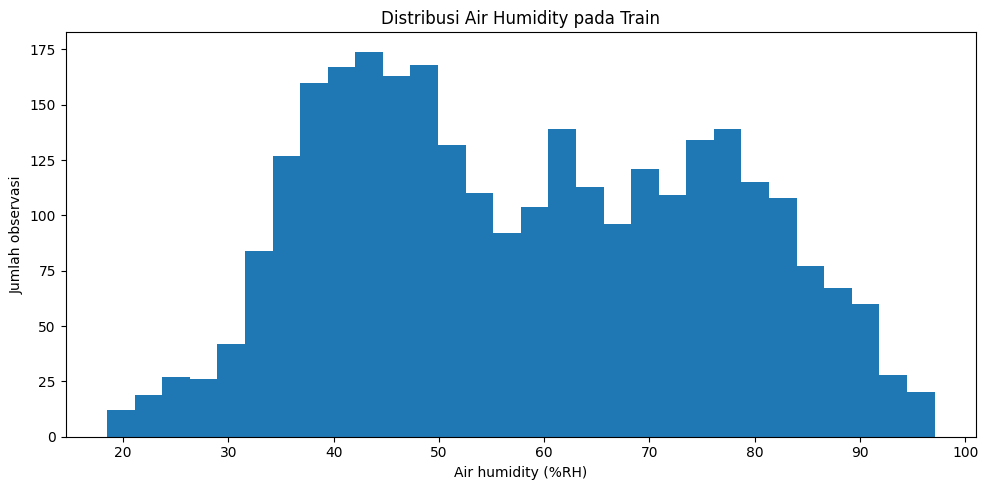

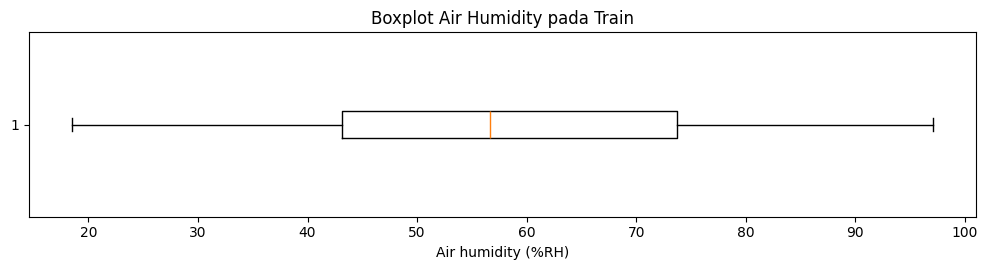

In [5]:
target_stats = train[TARGET].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame(TARGET)
display(target_stats)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train[TARGET].to_numpy(float), bins=30)
ax.set_title("Distribusi Air Humidity pada Train")
ax.set_xlabel("Air humidity (%RH)")
ax.set_ylabel("Jumlah observasi")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.boxplot(train[TARGET].to_numpy(float), vert=False)
ax.set_title("Boxplot Air Humidity pada Train")
ax.set_xlabel("Air humidity (%RH)")
plt.tight_layout()
plt.show()


### Interpretasi

EDA target menunjukkan bahwa target memiliki rentang dan variasi yang cukup lebar. Karena target test tidak tersedia, seluruh pemahaman distribusi target dibatasi pada train dan tidak digunakan untuk membuat klaim akurasi pada test.


# 06. EDA — Sensor Numerik, `env_id`, dan Missingness

---

## A. Statistik sensor numerik

### Mengapa analisis ini dilakukan

Feature engineering final membentuk ringkasan harian dan deviasi dari sensor lingkungan. Statistik deskriptif diperlukan untuk melihat skala, variasi, dan kolom yang benar-benar informatif secara struktural.


In [6]:
sensor_numeric_cols = [c for c in train.select_dtypes(include=[np.number]).columns if c not in [TARGET, "env_id"]]
sensor_summary = train[sensor_numeric_cols].describe().T.sort_values("std", ascending=False)
display(sensor_summary[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]])

if "env_id" in train.columns:
    print("env_id — jumlah unik train:", train["env_id"].nunique())
    print("env_id — jumlah unik test :", test["env_id"].nunique())
    print("env_id — missing train/test:", int(train["env_id"].isna().sum()), "/", int(test["env_id"].isna().sum()))
    print("env_id — digunakan sebagai fitur final:", "tidak")


,count,mean,std,min,25%,50%,75%,max
water_volume_line1,2648.0,19552.357844,12495.957393,-998.18,7676.4975,21318.575,30854.6150,39184.16
water_volume_line2,2654.0,13258.444484,7870.266272,-483.54,6036.4125,14040.355,20270.0325,25545.98
water_volume_line3,2659.0,8618.837108,4589.964122,-316.78,5027.3100,9748.930,12404.7600,15377.90
soil_ec_line3,2617.0,481.813393,396.736644,-1325.65,181.8100,344.890,781.8100,2374.14
soil_ec_line2,2648.0,408.423573,298.385097,-1007.45,175.2625,300.560,640.7550,1798.35
gdd,2635.0,405.530057,226.563679,-1.28,205.2800,420.960,592.7250,789.03
soil_ec_line1,2661.0,361.230699,138.985419,-264.19,264.4200,368.220,447.4900,1008.50
co2,2660.0,481.491184,49.214935,266.55,447.5350,468.935,502.3275,770.86
soil_humidity_line3,2656.0,26.904059,10.436863,7.69,20.2900,22.040,28.9800,57.13
soil_humidity_line2,2670.0,26.850034,8.559991,8.61,19.7900,24.280,33.5300,53.53


env_id — jumlah unik train: 2933
env_id — jumlah unik test : 734
env_id — missing train/test: 0 / 0
env_id — digunakan sebagai fitur final: tidak


### Interpretasi

`env_id` diperlakukan sebagai identifier dan tidak dimasukkan ke recipe feature final. Sensor lain dievaluasi berdasarkan variasi dan ketersediaannya. Missingness tidak otomatis dianggap sebagai alasan untuk menghapus feature, karena recipe sumber sudah menetapkan penanganan di tahap model.


## B. Korelasi sensor dengan target

### Mengapa analisis ini dilakukan

Korelasi digunakan sebagai **screening EDA**, bukan bukti kausal dan bukan satu-satunya dasar pemilihan fitur. Hubungan yang nonlinier tetap dapat ditangkap oleh model tree.


,korelasi_dengan_target
air_temperature,-0.837348
daily_max_above_Tbase,-0.296798
daily_max,-0.288340
soil_temp_line2,-0.245857
standard_day_degree,-0.234458
daily_mean_temperature,-0.227222
soil_temp_line3,-0.190466
water_volume_line3,-0.115290
water_volume_line1,-0.090446
water_volume_line2,-0.081915


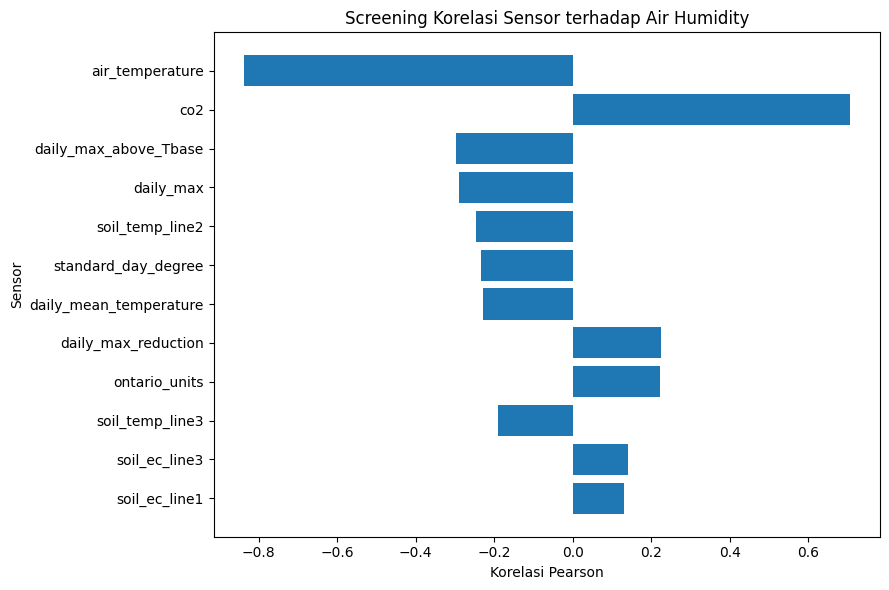

In [7]:
corr = train[sensor_numeric_cols].corrwith(train[TARGET]).sort_values()
display(corr.to_frame("korelasi_dengan_target"))

fig, ax = plt.subplots(figsize=(9, 6))
top = corr.abs().sort_values(ascending=False).head(12).index
ax.barh(top[::-1], corr.loc[top[::-1]])
ax.set_title("Screening Korelasi Sensor terhadap Air Humidity")
ax.set_xlabel("Korelasi Pearson")
ax.set_ylabel("Sensor")
plt.tight_layout()
plt.show()


### Interpretasi

Hubungan sensor–target digunakan untuk menjelaskan mengapa sensor lingkungan tetap dipertahankan sebagai sumber sinyal eksogen. Nilai korelasi tidak diterjemahkan menjadi hubungan sebab-akibat dan tidak digunakan untuk memangkas feature list final secara sepihak.


## C. Hubungan temperatur udara dan humidity

### Mengapa analisis ini dilakukan

Hubungan temperatur–kelembapan merupakan sinyal penting yang mendasari fitur berbasis temperatur dan **saturation vapour pressure** pada recipe final.


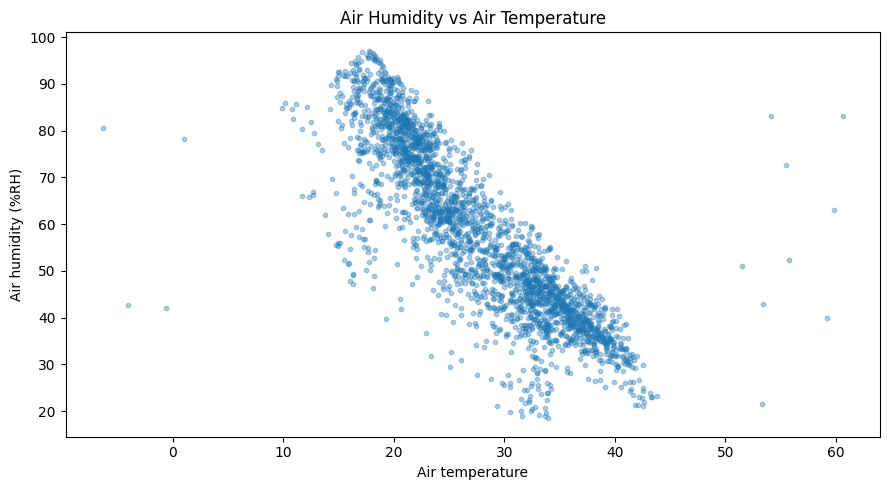

Korelasi air_temperature terhadap air_humidity: -0.8373


In [8]:
if "air_temperature" in train.columns:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(train["air_temperature"], train[TARGET], s=10, alpha=0.35)
    ax.set_title("Air Humidity vs Air Temperature")
    ax.set_xlabel("Air temperature")
    ax.set_ylabel("Air humidity (%RH)")
    plt.tight_layout()
    plt.show()

    temp_corr = train[["air_temperature", TARGET]].corr().iloc[0, 1]
    print("Korelasi air_temperature terhadap air_humidity: %.4f" % temp_corr)
else:
    print("air_temperature tidak tersedia; analisis dilewati.")


### Interpretasi

Relasi temperatur–humidity terlihat kuat pada EDA dan mendukung penggunaan temperatur aktual, variannya di dalam hari, serta transformasi fisik `es` pada feature engineering. Ini adalah **justifikasi berbasis EDA**, bukan klaim hubungan kausal.


# 07. EDA — Sensor Tanah, Irigasi, dan Fitur Thermal

---

## A. Sensor tanah dan humidity

### Mengapa analisis ini dilakukan

Sensor tanah merupakan sumber sinyal eksogen yang digunakan dalam recipe Tahap 2. Hubungan agregat/spesifik dengan humidity diperiksa agar penggunaannya mempunyai konteks EDA.


,korelasi_dengan_air_humidity
soil_temp_line2,-0.245857
soil_temp_line3,-0.190466
soil_temp_line1,-0.050367
soil_humidity_line1,-0.032861
soil_humidity_line2,0.011619
soil_ec_line2,0.090524
soil_humidity_line3,0.118633


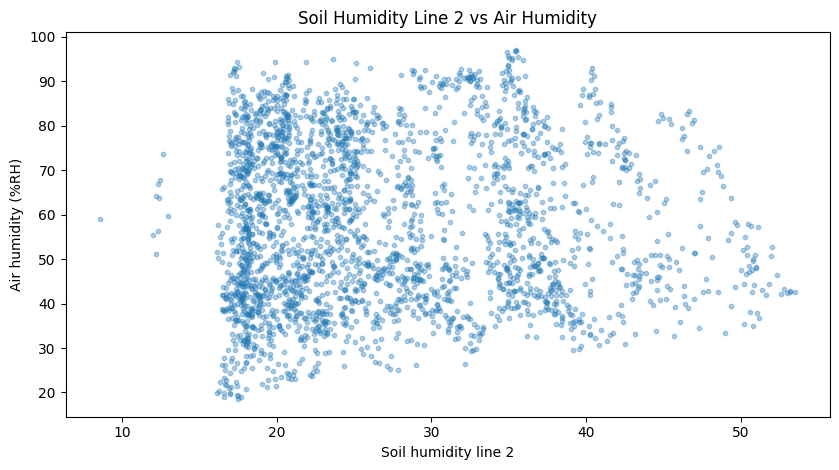

In [9]:
soil_cols = [c for c in [
    "soil_humidity_line1", "soil_humidity_line2", "soil_humidity_line3",
    "soil_temp_line1", "soil_temp_line2", "soil_temp_line3",
    "soil_ec_line2"
] if c in train.columns]

soil_corr = train[soil_cols].corrwith(train[TARGET]).sort_values()
display(soil_corr.to_frame("korelasi_dengan_air_humidity"))

if "soil_humidity_line2" in train.columns:
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.scatter(train["soil_humidity_line2"], train[TARGET], s=10, alpha=0.35)
    ax.set_title("Soil Humidity Line 2 vs Air Humidity")
    ax.set_xlabel("Soil humidity line 2")
    ax.set_ylabel("Air humidity (%RH)")
    plt.tight_layout()
    plt.show()


### Interpretasi

Hubungan sensor tanah dipakai sebagai pemeriksaan kelayakan sinyal eksogen. Feature tetap mengikuti recipe sumber; korelasi EDA tidak dipakai untuk mengubah daftar feature final secara sepihak.


## B. Sinyal irigasi / water volume

### Mengapa analisis ini dilakukan

Fitur `water_volume_line1–3` berada dalam kelompok sensor eksogen. Pemeriksaan ini membantu melihat apakah perubahan volume memiliki hubungan sederhana dengan humidity dan apakah ada indikasi nilai ekstrem.


,korelasi_dengan_air_humidity
water_volume_line3,-0.115290
water_volume_line1,-0.090446
water_volume_line2,-0.081915


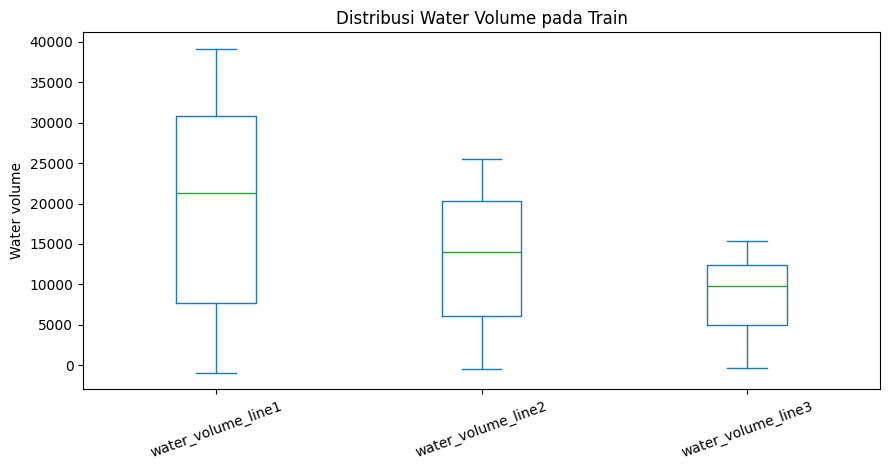

In [10]:
water_cols = [c for c in ["water_volume_line1", "water_volume_line2", "water_volume_line3"] if c in train.columns]
water_corr = train[water_cols].corrwith(train[TARGET]).sort_values()
display(water_corr.to_frame("korelasi_dengan_air_humidity"))

if water_cols:
    fig, ax = plt.subplots(figsize=(9, 4.8))
    train[water_cols].plot(kind="box", ax=ax)
    ax.set_title("Distribusi Water Volume pada Train")
    ax.set_ylabel("Water volume")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


### Interpretasi

Hubungan water volume dibaca sebagai sinyal eksogen, bukan bukti kausal. Nilai ekstrem diaudit tetapi tidak dihapus karena pipeline final tidak melakukan pembersihan outlier agresif.


## C. Fitur `daily_*`, GDD, dan indikator thermal

### Mengapa analisis ini dilakukan

Feature engineering Tahap 1 menggunakan ringkasan dan indikator termal harian. Karena feature tersebut masuk ke model final, coverage dan konsistensinya harus terlihat pada train dan test.


,missing_train,missing_test,nunique_train,nunique_test,missing_pct_train,missing_pct_test
daily_mean_temperature,283,124,802,260,9.648824,16.893733
daily_max,277,129,989,281,9.444255,17.574932
daily_max_above_Tbase,303,128,991,293,10.330719,17.438692
daily_max_reduction,291,108,866,258,9.921582,14.713896
standard_day_degree,290,113,813,268,9.887487,15.395095
ontario_units,305,110,616,187,10.398909,14.986376
gdd,298,114,2591,585,10.160245,15.531335


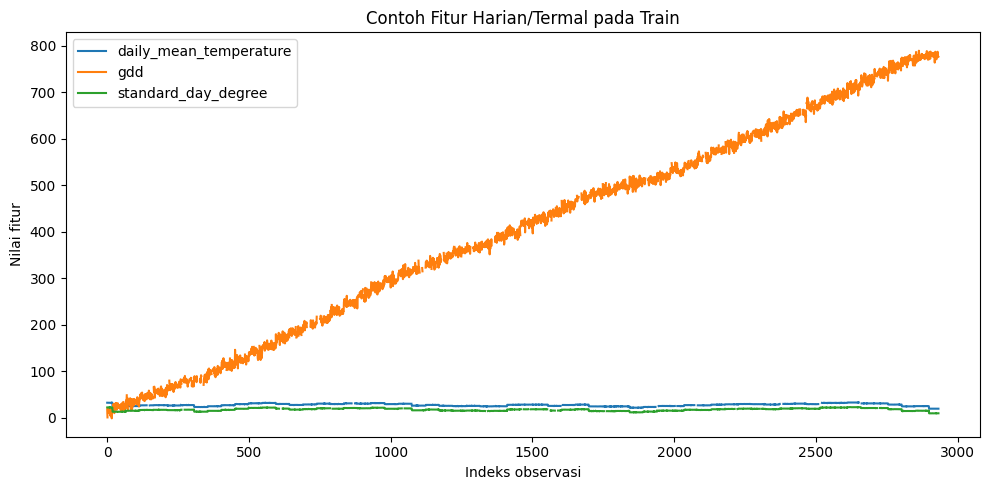

In [11]:
thermal_cols = [c for c in [
    "daily_mean_temperature", "daily_max", "daily_max_above_Tbase",
    "daily_max_reduction", "standard_day_degree", "ontario_units", "gdd"
] if c in train.columns]

thermal_audit = pd.DataFrame({
    "missing_train": train[thermal_cols].isna().sum(),
    "missing_test": test[thermal_cols].isna().sum(),
    "nunique_train": train[thermal_cols].nunique(),
    "nunique_test": test[thermal_cols].nunique(),
})
thermal_audit["missing_pct_train"] = 100 * thermal_audit["missing_train"] / len(train)
thermal_audit["missing_pct_test"] = 100 * thermal_audit["missing_test"] / len(test)
display(thermal_audit)

fig, ax = plt.subplots(figsize=(10, 5))
subset = [c for c in ["daily_mean_temperature", "gdd", "standard_day_degree"] if c in train.columns]
if subset:
    train[subset].plot(ax=ax)
    ax.set_title("Contoh Fitur Harian/Termal pada Train")
    ax.set_xlabel("Indeks observasi")
    ax.set_ylabel("Nilai fitur")
    ax.legend()
    plt.tight_layout()
    plt.show()


### Interpretasi

Fitur harian dan indikator thermal diperiksa khusus karena dipakai oleh Tahap 1. Missingness dan coverage dicatat tanpa melakukan imputasi global di EDA; penanganan aktual tetap dilakukan di dalam recipe model.


# 08. EDA — Struktur Temporal dan Intraday

---

## A. Kontinuitas waktu

### Mengapa analisis ini dilakukan

Model dibangun pada urutan waktu. Interval pengamatan menjadi dasar pembentukan slot 30 menit, lag sensor, serta validasi temporal.


Train: 2023-06-29 06:00:00 → 2023-08-29 14:30:00
Test : 2023-08-29 15:00:00 → 2023-09-13 21:30:00
Frekuensi gap train:


,jumlah
datetime,
0 days 00:30:00,2931
0 days 07:00:00,1


Frekuensi gap test:


,jumlah
datetime,
0 days 00:30:00,733


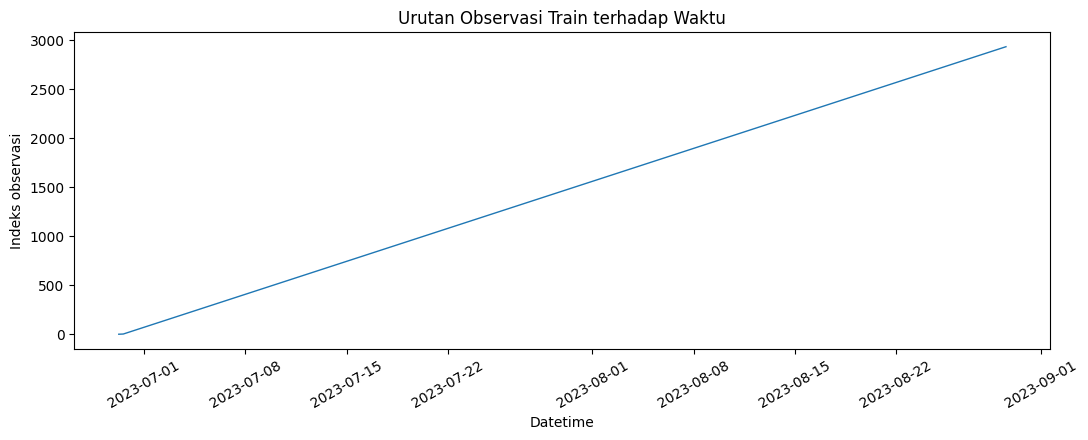

In [12]:
print("Train:", train[KEY].min(), "→", train[KEY].max())
print("Test :", test[KEY].min(), "→", test[KEY].max())

print("Frekuensi gap train:")
display(train_gap.value_counts().head(10).rename("jumlah").to_frame())
print("Frekuensi gap test:")
display(test_gap.value_counts().head(10).rename("jumlah").to_frame())

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(train[KEY], np.arange(len(train)), linewidth=1)
ax.set_title("Urutan Observasi Train terhadap Waktu")
ax.set_xlabel("Datetime")
ax.set_ylabel("Indeks observasi")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Interpretasi

Struktur observasi menunjukkan pola pengukuran 30 menit dengan gap yang perlu dicatat, bukan ditutupi. Karena urutan waktu nyata penting, validasi acak tidak dipakai sebagai validasi utama.


## B. Drift level mingguan

### Mengapa analisis ini dilakukan

Tahap 1 dirancang untuk memodelkan level harian. Perubahan level antar-periode diuji agar keputusan dekomposisi tidak hanya berdasarkan asumsi.


,mean,std,min,max,count
minggu,,,,,
0,66.379257,18.138172,32.19,97.09,323
1,57.527530,16.553513,31.23,92.72,336
2,54.844524,15.880644,29.45,88.24,336
3,61.809137,16.980610,23.70,93.43,336
4,58.504911,14.979435,32.99,91.39,336
5,52.799256,20.248313,18.47,94.94,336
6,57.849613,17.858129,29.80,88.14,336
7,54.459911,17.366616,22.98,87.79,336
8,60.306822,20.201893,21.21,92.54,258


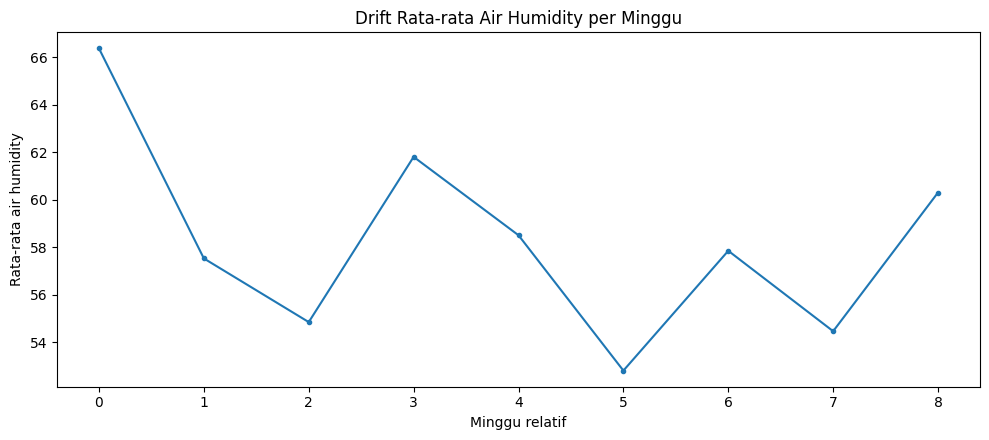

Perubahan mean minggu pertama → terakhir: -6.0724


In [13]:
t_eda = train.assign(
    minggu=((train[KEY] - train[KEY].min()).dt.days // 7),
    jam=train[KEY].dt.hour
)
weekly = t_eda.groupby("minggu")[TARGET].agg(["mean", "std", "min", "max", "count"])
display(weekly)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(weekly.index, weekly["mean"], marker="o", markersize=3)
ax.set_title("Drift Rata-rata Air Humidity per Minggu")
ax.set_xlabel("Minggu relatif")
ax.set_ylabel("Rata-rata air humidity")
plt.tight_layout()
plt.show()

print("Perubahan mean minggu pertama → terakhir: %.4f" % (weekly["mean"].iloc[-1] - weekly["mean"].iloc[0]))


### Interpretasi

Perubahan level antar-minggu menunjukkan bahwa satu model direct harus mempelajari perubahan level rendah-frekuensi sekaligus pola intraday. Temuan ini menjadi **justifikasi EDA untuk Tahap 1 daily level**.


## C. Pola intraday 48 slot

### Mengapa analisis ini dilakukan

Dengan interval 30 menit, satu hari terdiri dari 48 slot. Profil ini menguji apakah pola berulang dalam satu hari cukup jelas untuk mendukung harmonic features dan pemodelan deviation.


,mean,std,count
slot,,,
0,73.108033,10.603671,61
1,74.579672,10.451921,61
2,76.049016,10.145209,61
3,76.727049,9.905114,61
4,77.473607,9.598077,61
5,78.491311,8.734752,61
6,79.475082,8.517651,61
7,80.539344,8.467998,61
8,80.989180,8.514634,61


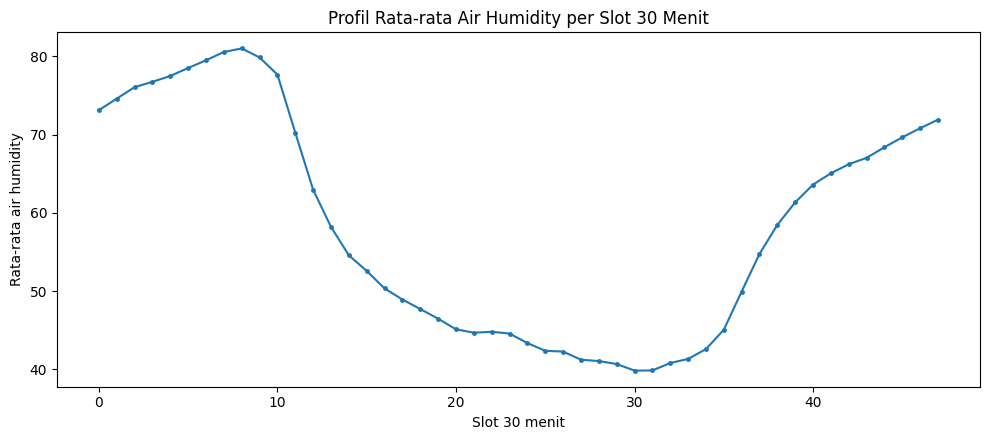

Rentang mean antar-slot: 41.1341


In [14]:
intraday = train.assign(slot=(train[KEY].dt.hour * 2 + train[KEY].dt.minute // 30).astype(int))
slot_profile = intraday.groupby("slot")[TARGET].agg(["mean", "std", "count"])
display(slot_profile)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(slot_profile.index, slot_profile["mean"], marker="o", markersize=2.5)
ax.set_title("Profil Rata-rata Air Humidity per Slot 30 Menit")
ax.set_xlabel("Slot 30 menit")
ax.set_ylabel("Rata-rata air humidity")
plt.tight_layout()
plt.show()

print("Rentang mean antar-slot: %.4f" % (slot_profile["mean"].max() - slot_profile["mean"].min()))


### Interpretasi

Variasi intraday yang terlihat mendukung dua keputusan: (1) penggunaan Fourier harmonics untuk pola waktu-hari, dan (2) Tahap 2 yang bekerja pada komponen deviation agar level harian tidak perlu dipelajari ulang oleh satu model.


## D. Profil harian dan variasi dalam hari

### Mengapa analisis ini dilakukan

Dekomposisi dua tahap membutuhkan bukti bahwa variasi antar-hari dan variasi dalam hari memang merupakan dua sumber variasi yang berbeda.


,mean,std,min,max,count
hari,,,,,
2023-06-29,46.480870,10.765804,32.19,65.53,23
2023-06-30,83.889167,11.056047,60.39,96.21,48
2023-07-01,76.094583,19.969346,42.53,97.09,48
2023-07-02,60.919792,17.243309,41.64,91.94,48
2023-07-03,63.900208,14.019792,44.11,84.11,48
2023-07-04,60.322500,15.259949,39.60,83.18,48
2023-07-05,59.752500,13.651734,42.78,83.89,48
2023-07-06,68.023333,12.652023,47.89,89.33,48
2023-07-07,58.713958,19.637964,37.12,92.72,48


,count,mean,std,min,25%,50%,75%,max
mean,62.0,58.222124,8.603364,42.899792,52.572865,57.559062,61.084271,83.889167
std,62.0,15.667526,3.466325,7.541325,13.512326,15.460246,18.021742,25.159449
min,62.0,36.786129,8.866434,18.470000,31.972500,36.845000,41.292500,63.300000
max,62.0,83.940323,7.591298,62.560000,79.410000,85.105000,89.045000,97.090000


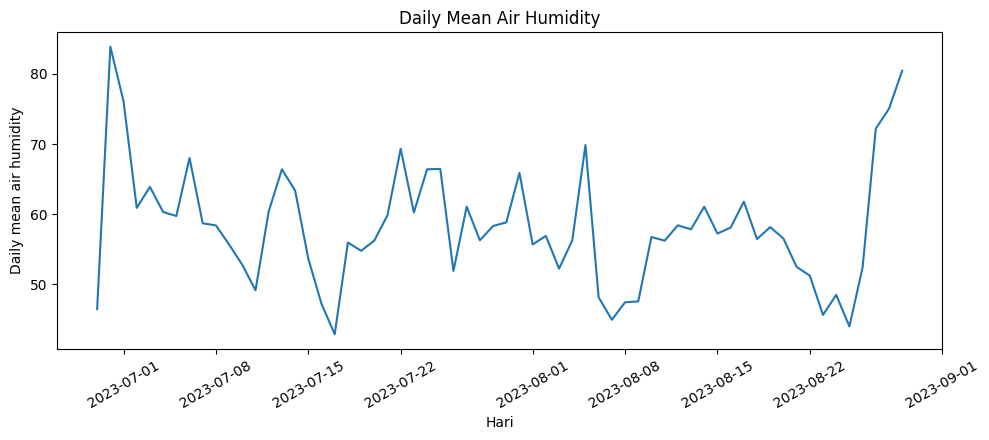

In [15]:
daily_target = (
    train.assign(hari=train[KEY].dt.floor("D"))
         .groupby("hari")[TARGET]
         .agg(["mean", "std", "min", "max", "count"])
)

display(daily_target.head(10))
display(daily_target[["mean", "std", "min", "max"]].describe().T)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(daily_target.index, daily_target["mean"])
ax.set_title("Daily Mean Air Humidity")
ax.set_xlabel("Hari")
ax.set_ylabel("Daily mean air humidity")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Interpretasi

Daily mean menunjukkan perubahan level antar-hari, sedangkan standar deviasi harian menunjukkan variasi di dalam hari. Keduanya merupakan justifikasi EDA yang langsung mengarah pada **Tahap 1 = level** dan **Tahap 2 = deviation**.


# 09. EDA — Autokorelasi Target dan Pencegahan Leakage

---

### Mengapa analisis ini dilakukan

Autokorelasi membantu mengukur seberapa kuat dependensi temporal target pada data train. Namun, kekuatan tersebut sekaligus menunjukkan mengapa target lag dapat menjadi sumber leakage ketika target masa depan tidak tersedia pada test.


,lag_slot,lag_jam,korelasi
0,1,0.5,0.979233
1,2,1.0,0.936826
2,3,1.5,0.880390
3,6,3.0,0.665387
4,12,6.0,0.194488
5,24,12.0,-0.475708
6,48,24.0,0.757240
7,72,36.0,-0.610128
8,96,48.0,0.686480


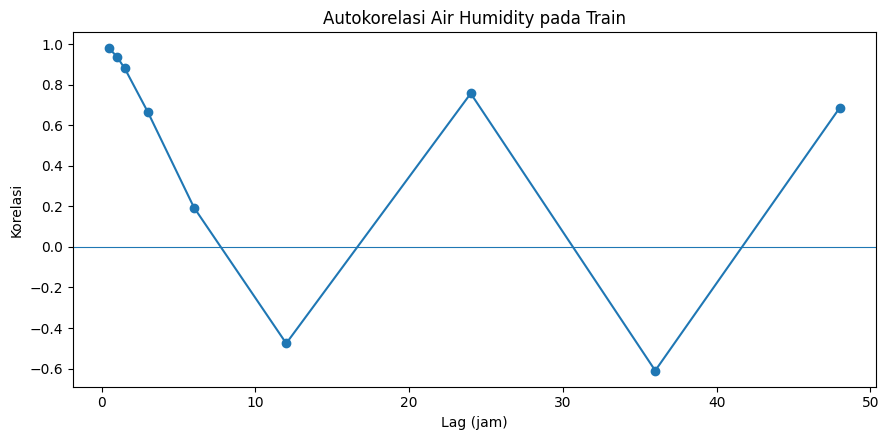

In [16]:
target_values = train[TARGET].to_numpy(float)

def corr_lag(v, lag):
    v = np.asarray(v, float)
    if lag >= len(v):
        return np.nan
    a = v[:-lag]
    b = v[lag:]
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

lags = [1, 2, 3, 6, 12, 24, 48, 72, 96]
acf_table = pd.DataFrame([
    {"lag_slot": L, "lag_jam": 0.5 * L, "korelasi": corr_lag(target_values, L)}
    for L in lags
])
display(acf_table)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(acf_table["lag_jam"], acf_table["korelasi"], marker="o")
ax.axhline(0, linewidth=0.8)
ax.set_title("Autokorelasi Air Humidity pada Train")
ax.set_xlabel("Lag (jam)")
ax.set_ylabel("Korelasi")
plt.tight_layout()
plt.show()


### Interpretasi

Autokorelasi target menunjukkan adanya dependensi waktu yang kuat pada train. **Target lag tidak digunakan sebagai feature produksi**, karena nilai target pada periode test belum tersedia. Struktur temporal ditangkap melalui sensor eksogen, kalender, fitur lag sensor yang sah, dan smoothing output.


# 10. EDA — Train vs Test, Outlier, dan Batas Fisik

---

## A. Distribution shift pada fitur eksogen

### Mengapa analisis ini dilakukan

Model akan melakukan inference pada distribusi test. Perbandingan sederhana train–test digunakan untuk mengetahui apakah terdapat pergeseran skala pada sensor yang harus dipertimbangkan saat membaca hasil model.


In [17]:
common_numeric = [c for c in test.select_dtypes(include=[np.number]).columns if c in train.columns and c != "env_id"]
shift_rows = []
for c in common_numeric:
    tr = pd.to_numeric(train[c], errors="coerce")
    te = pd.to_numeric(test[c], errors="coerce")
    if tr.notna().sum() == 0 or te.notna().sum() == 0:
        continue
    shift_rows.append({
        "fitur": c,
        "train_mean": float(tr.mean()),
        "test_mean": float(te.mean()),
        "beda_mean": float(te.mean() - tr.mean()),
        "train_std": float(tr.std()),
        "test_std": float(te.std()),
        "rasio_std": float(te.std() / (tr.std() + 1e-9)),
    })

shift_table = (
    pd.DataFrame(shift_rows)
      .assign(abs_beda_mean=lambda d: d["beda_mean"].abs())
      .sort_values("abs_beda_mean", ascending=False)
)
display(shift_table.head(20))


,fitur,train_mean,test_mean,beda_mean,train_std,test_std,rasio_std,abs_beda_mean
13,water_volume_line1,19552.357844,38280.000000,18727.642156,12495.957393,0.000000,0.000000,18727.642156
14,water_volume_line2,13258.444484,25028.000000,11769.555516,7870.266272,0.000000,0.000000,11769.555516
15,water_volume_line3,8618.837108,15094.000000,6475.162892,4589.964122,0.000000,0.000000,6475.162892
16,gdd,405.530057,841.695758,436.165701,226.563679,31.921264,0.140893,436.165701
10,soil_ec_line3,481.813393,225.397152,-256.416242,396.736644,90.644764,0.228476,256.416242
7,soil_ec_line2,408.423573,182.141875,-226.281698,298.385097,71.172637,0.238526,226.281698
4,soil_ec_line1,361.230699,228.976656,-132.254043,138.985419,91.695606,0.659750,132.254043
8,soil_humidity_line2,26.850034,20.284522,-6.565511,8.559991,1.783725,0.208379,6.565511
11,soil_humidity_line3,26.904059,21.729449,-5.174610,10.436863,1.567668,0.150205,5.174610
1,pressure,1008.875511,1013.284271,4.408760,5.239859,4.581034,0.874267,4.408760


### Interpretasi

Distribusi sensor tidak diasumsikan identik antara train dan test. Hal ini konsisten dengan penggunaan ensemble tree dan agregasi sensor pada recipe final. EDA shift dipakai untuk memahami robustness, bukan untuk menghapus feature satu per satu secara ad hoc.


## B. Audit outlier sensor dan target

### Mengapa analisis ini dilakukan

Nilai ekstrem dapat berasal dari kondisi lingkungan maupun gangguan sensor. Karena recipe sumber tidak melakukan penghapusan outlier secara global, EDA digunakan untuk **mengaudit**, bukan membersihkan secara agresif.


In [18]:
outlier_rows = []
for c in [TARGET] + sensor_numeric_cols:
    s = pd.to_numeric(train[c], errors="coerce").dropna()
    if len(s) == 0:
        continue
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    outlier_rows.append({
        "fitur": c,
        "batas_bawah_iqr": float(low),
        "batas_atas_iqr": float(high),
        "jumlah_outlier_iqr": int(mask.sum()),
        "persen_outlier_iqr": float(100 * mask.mean()),
    })

outlier_table = pd.DataFrame(outlier_rows).sort_values("persen_outlier_iqr", ascending=False)
display(outlier_table.head(20))

if 0 <= train[TARGET].min() and train[TARGET].max() <= 100:
    print("Target train seluruhnya berada pada rentang 0–100 %RH.")
else:
    print("Target train memiliki nilai di luar 0–100 %RH; pemeriksaan perlu diperhatikan.")


,fitur,batas_bawah_iqr,batas_atas_iqr,jumlah_outlier_iqr,persen_outlier_iqr
12,soil_humidity_line3,7.25500,42.01500,430,16.189759
1,co2,365.34625,584.51625,114,4.285714
10,soil_temp_line2,19.26500,29.78500,84,3.175803
6,soil_humidity_line1,15.39125,37.36125,65,2.469605
5,soil_ec_line1,-10.18500,722.09500,56,2.104472
2,pressure,996.03000,1022.21000,51,1.928896
23,ontario_units,21.52500,31.32500,45,1.712329
20,daily_max_above_Tbase,16.53375,37.40375,33,1.254753
7,soil_temp_line1,19.71000,28.03000,33,1.246694
21,daily_max,26.41375,47.54375,31,1.167169


Target train seluruhnya berada pada rentang 0–100 %RH.


### Interpretasi

Outlier tidak otomatis dihapus karena dapat merupakan kondisi nyata dan penghapusan akan mengubah perilaku model sumber. Rentang fisik `0–100 %RH` menjadi sanity constraint pada output akhir, bukan alasan untuk memotong target train secara sembarangan.


# 11. Kesimpulan EDA → Keputusan Modeling

---

Bagian ini menjadi jembatan eksplisit antara observasi data dan recipe teknis. **Tidak ada keputusan model yang dibuat dari EDA ini selain keputusan yang memang sudah menjadi bagian dari recipe final sumber.** EDA berfungsi memberi justifikasi dan konteks.


### Temuan EDA utama

1. **Struktur waktu 30 menit dan adanya gap tertentu** → urutan waktu dipertahankan; validasi utama menggunakan rolling-origin temporal.
2. **Variasi daily mean antar-periode** → Tahap 1 dipakai untuk memodelkan daily level.
3. **Pola intraday yang jelas pada 48 slot** → harmonic features dan Tahap 2 deviation dipertahankan.
4. **Hubungan kuat temperatur–humidity** → `air_temperature`, `es`, deviasi temperatur, dan fitur fisik terkait dipertahankan.
5. **Sensor eksogen memiliki variasi dan missingness** → agregasi harian, deviasi, dan imputasi di dalam recipe dipertahankan.
6. **Autokorelasi target kuat pada train** → target lag sengaja tidak digunakan pada inference untuk mencegah leakage.
7. **Distribusi train–test tidak selalu identik** → ensemble tree dan agregasi dipertahankan sebagai recipe yang lebih sesuai dengan sinyal heterogen.
8. **Target berada pada skala fisik 0–100 %RH** → clipping final dipertahankan sebagai sanity constraint.

### Prinsip penting

> **EDA menjustifikasi struktur pipeline, bukan digunakan untuk memanipulasi skor atau memilih data secara retrospektif.**


# 12. Pencegahan Kebocoran Informasi dan Informasi yang Sah

---

### Informasi yang sah

- sensor eksogen yang tersedia pada `test.csv`;
- `datetime`;
- fitur turunan dari informasi sensor dan waktu yang sah;
- statistik train yang dihitung di dalam fold ketika validasi temporal;
- recipe smoothing/post-processing yang sudah dibekukan sebelum finalization.

### Informasi yang tidak sah

- `air_humidity` masa depan pada test;
- target validation yang belum tersedia saat prediksi;
- target lag atau rolling target yang bergantung pada future target;
- ground truth test;
- reference CSV atau submission lama;
- data eksternal, internet, API, atau scraping.

### Mengapa target lag tidak dipakai

Autokorelasi target dapat sangat tinggi. Justru karena itu, feature `air_humidity` lag dapat memberikan validasi yang tampak sangat kuat tetapi tidak dapat direplikasi pada test ketika target masa depan tidak diketahui. Recipe final hanya menggunakan lag pada **sensor eksogen**.


# 13. Pra-pemrosesan sebelum Pemodelan

---

### Metodologi

Recipe final tidak menggunakan satu tahap imputasi global yang mengubah seluruh dataset. Penanganan missing dilakukan **di titik penggunaan feature** sesuai sumber: tabel harian Tahap 1 menggunakan median yang dihitung dari data training fold, sedangkan model tree Tahap 2 dan direct ensemble menggunakan `fillna(0.0)`.

### EDA justification

EDA menunjukkan bahwa missingness tersebar pada sejumlah sensor. Karena itu, preprocessing dipertahankan lokal agar tidak menambah asumsi baru dan agar perilaku recipe sumber tetap sama. `env_id` tidak digunakan sebagai predictive feature karena diperlakukan sebagai identifier.


In [19]:
print("Strategi preprocessing final:")
print(" - Stage 1: imputasi median pada fitur tabel harian, dihitung dari data training.")
print(" - Stage 2: missing feature tree diisi 0.0 sesuai recipe sumber.")
print(" - Direct ensemble: missing feature diisi 0.0 sesuai recipe sumber.")
print(" - Tidak ada imputasi target test dan tidak ada target lag.")


Strategi preprocessing final:
 - Stage 1: imputasi median pada fitur tabel harian, dihitung dari data training.
 - Stage 2: missing feature tree diisi 0.0 sesuai recipe sumber.
 - Direct ensemble: missing feature diisi 0.0 sesuai recipe sumber.
 - Tidak ada imputasi target test dan tidak ada target lag.


### Interpretasi

Preprocessing diperlakukan sebagai bagian dari recipe modeling, bukan sebagai tahap pembersihan terpisah yang bebas diubah. Dengan demikian, EDA memberi konteks terhadap masalah missingness, sedangkan implementasi tetap konsisten dengan notebook sumber.


# 14. Rekayasa Fitur

---

### Metodologi

Feature engineering final dipertahankan dari notebook sumber. Justifikasi EDA-nya sudah ditunjukkan pada bagian sebelumnya: pola daily level, pola intraday 48 slot, hubungan temperatur–humidity, variasi sensor, serta dependensi temporal pada sensor.

Tidak ada feature baru yang ditambahkan pada tahap finalization, dan tidak ada formula atau window yang diubah.


In [20]:
def esf(x):        # Magnus saturation vapour pressure (kPa)
    x = np.asarray(x, float)
    return 0.6108*np.exp(17.27*x/(x+237.3))

DRIV = ["air_temperature","es","co2","pressure",
        "soil_temp_line1","soil_temp_line2","soil_temp_line3",
        "soil_humidity_line1","soil_humidity_line2","soil_humidity_line3","soil_ec_line2"]

DAG  = ["daily_mean_temperature","daily_max","daily_max_above_Tbase","daily_max_reduction",
        "standard_day_degree","ontario_units","gdd"]

full = pd.concat(
    [train, test],
    ignore_index=True
).sort_values(
    "datetime"
).reset_index(drop=True)

full["es"] = esf(
    full["air_temperature"]
)

full["day"] = full.datetime.dt.floor("D")
full["slot"] = (
    full.datetime.dt.hour*2
    + full.datetime.dt.minute//30
).astype(int)

for c in DRIV:
    g = full.groupby("day")[c]
    full[c+"_dm"] = g.transform("mean")
    full[c+"_dsd"] = g.transform("std")
    full[c+"_dmin"] = g.transform("min")
    full[c+"_dmax"] = g.transform("max")
    full[c+"_dev"] = full[c] - full[c+"_dm"]

full["phys_ratio"] = (
    esf(full["air_temperature_dm"])
    / full["es"]
)

for k in range(1, 11):
    full[f"sh{k}"] = np.sin(
        2*np.pi*k*full.slot/48
    )
    full[f"ch{k}"] = np.cos(
        2*np.pi*k*full.slot/48
    )

HARM = (
    [f"sh{k}" for k in range(1,11)]
    + [f"ch{k}" for k in range(1,11)]
)

full["dT"] = full["air_temperature_dev"]
full["des"] = full["es_dev"]
full["dT2"] = full["dT"]**2
full["dTdes"] = (
    full["dT"]*full["des"]
)

for f in [
    "dT",
    "des",
    "soil_humidity_line2_dev",
    "co2_dev"
]:
    for L in [1,2,3,6,12]:
        full[f"{f}_l{L}"] = (
            full.groupby("day")[f]
            .shift(L)
        )

DFEAT = list(
    dict.fromkeys(
        DAG
        + [
            c+s
            for c in DRIV
            for s in [
                "_dm",
                "_dsd",
                "_dmin",
                "_dmax"
            ]
        ]
    )
)

dtf = (
    full.groupby("day")
    .agg(
        **{
            f:(f,"first")
            for f in DFEAT
        }
    )
)

dtf["doy"] = dtf.index.dayofyear

S2 = (
    [
        "dT",
        "des",
        "dT2",
        "dTdes",
        "phys_dev",
        "phys_ratio"
    ]
    + [
        c+"_dev"
        for c in DRIV
    ]
    + [
        "slot",
        "air_temperature_dsd",
        "es_dsd"
    ]
    + HARM
    + [
        f"{f}_l{L}"
        for f in [
            "dT",
            "des",
            "soil_humidity_line2_dev",
            "co2_dev"
        ]
        for L in [1,2,3,6,12]
    ]
    + [
        f"phys_dev_l{L}"
        for L in [1,2,3,6,12]
    ]
)

S2 = list(dict.fromkeys(S2))

S2B = list(
    dict.fromkeys(
        S2
        + DAG
        + [
            "air_temperature_dm",
            "es_dm",
            "co2_dm",
            "pressure_dm",
            "soil_humidity_line2_dm",
            "soil_temp_line2_dm"
        ]
    )
)

DIRECT_RAW = [
    "co2","pressure","air_temperature","es",
    "soil_ec_line1","soil_humidity_line1","soil_temp_line1",
    "soil_ec_line2","soil_humidity_line2","soil_temp_line2",
    "soil_ec_line3","soil_humidity_line3","soil_temp_line3",
    "water_volume_line1","water_volume_line2","water_volume_line3",
    "gdd","standard_day_degree","daily_mean_temperature",
    "daily_max_above_Tbase","daily_max",
    "daily_max_reduction","ontario_units"
]

DIRECT_COLS = (
    DIRECT_RAW
    + HARM
    + [c+"_dm" for c in DRIV]
    + [c+"_dev" for c in DRIV]
    + ["phys_ratio"]
)

print("Fitur Tahap 1:", dtf.shape[1])
print("Fitur Tahap 2 A/B:", len(S2), "/", len(S2B))
print("Fitur direct ensemble:", len(DIRECT_COLS))
print("Jumlah fitur dibentuk sesuai recipe final sumber.")


Fitur Tahap 1: 52
Fitur Tahap 2 A/B: 65 / 78
Fitur direct ensemble: 66
Jumlah fitur dibentuk sesuai recipe final sumber.


### Output dan interpretasi

Rekayasa fitur menghasilkan tiga kelompok utama:

- **fitur Tahap 1** untuk level harian;
- **fitur Tahap 2 A/B** untuk deviation intraday;
- **fitur direct ensemble** sebagai pembanding.

Urutan dan daftar feature tidak diubah agar perilaku model final tetap konsisten dengan recipe sumber.


# 15. Tahap 1 — Model Rata-rata Harian Kelembapan

---

### Metodologi

Tahap 1 memodelkan komponen **daily mean humidity** sebagai level dasar. EDA pada daily profile dan drift mingguan menunjukkan bahwa level antar-hari berubah sepanjang waktu, sehingga memisahkan level dari variasi intraday merupakan pilihan yang dapat dijelaskan secara data-driven.

Model yang dipertahankan:

- Ridge sebagai komponen linear;
- LightGBM sebagai model tree ensemble;
- XGBoost sebagai model tree ensemble kedua;
- gabungan internal dengan bobot recipe sumber;
- carry-over residual AR(1)-style pada batas train → test.

### EDA justification

Daily mean yang berubah antar-periode → perlu ada model level khusus. Carry-over hanya menggunakan residual yang sudah tersedia pada sisi train dan meredam pengaruhnya secara bertahap ke hari berikutnya.


In [21]:
MODEL_REGISTRY = {}

y = train[TARGET].to_numpy(float)

tr_daymean = (
    full.iloc[:N]
    .groupby("day")[TARGET]
    .mean()
)

def stage1_base(train_days, daymean, registry_prefix=None):
    d = dtf.loc[train_days]
    l = daymean.reindex(train_days)

    med = d.median()
    Xd = d.fillna(med)

    sc = StandardScaler().fit(Xd)

    r1 = Ridge(alpha=6).fit(
        sc.transform(Xd),
        l.values
    )

    gb = lgb.LGBMRegressor(
        n_estimators=250,
        learning_rate=0.035,
        num_leaves=8,
        reg_lambda=8,
        min_child_samples=6,
        subsample=0.9,
        subsample_freq=1,
        random_state=1,
        n_jobs=1,
        verbosity=-1,
        deterministic=True,
        force_row_wise=True
    ).fit(
        Xd.values,
        l.values
    )

    xb = xgb.train(
        dict(
            max_depth=2,
            eta=0.04,
            subsample=0.9,
            reg_lambda=8,
            nthread=1,
            seed=1
        ),
        xgb.DMatrix(
            Xd.values,
            label=l.values,
            feature_names=list(Xd.columns)
        ),
        200
    )

    if registry_prefix is not None:
        MODEL_REGISTRY[f"{registry_prefix}_ridge"] = r1
        MODEL_REGISTRY[f"{registry_prefix}_ridge_scaler"] = sc
        MODEL_REGISTRY[f"{registry_prefix}_lgbm"] = gb
        MODEL_REGISTRY[f"{registry_prefix}_xgb"] = xb
        MODEL_REGISTRY[f"{registry_prefix}_features"] = list(Xd.columns)

    Xa = dtf.fillna(med)

    p = (
        0.40*r1.predict(
            sc.transform(Xa)
        )
        + 0.35*gb.predict(
            Xa.values
        )
        + 0.25*xb.predict(
            xgb.DMatrix(
                Xa.values,
                feature_names=list(Xa.columns)
            )
        )
    )

    p = pd.Series(
        p,
        index=dtf.index
    )

    return (
        0.85*p
        + 0.15*float(
            l.tail(10).mean()
        )
    )

CARRY_RHO = 0.30
CARRY_W = 0.60
CARRY_NLAST = 3

def stage1(train_days, daymean, future_days, registry_prefix=None):
    base = stage1_base(
        train_days,
        daymean,
        registry_prefix=registry_prefix
    )

    resid = (
        daymean.reindex(train_days)
        - base.reindex(train_days)
    ).dropna()

    r0 = float(
        resid.tail(
            CARRY_NLAST
        ).mean()
    )

    out = base.copy()

    for k, dd in enumerate(
        future_days
    ):
        if dd in out.index:
            out[dd] = (
                base[dd]
                + CARRY_W*r0*(
                    CARRY_RHO**k
                )
            )

    return (
        out,
        base,
        r0,
        float(
            resid.autocorr(1) or 0.0
        )
    )

train_days = list(
    full.iloc[:N].day.unique()
)

test_days = list(
    pd.Index(
        test["datetime"]
        .dt.floor("D")
        .unique()
    )
)

lvl_series, lvl_base, r0, ac1 = stage1(
    train_days,
    tr_daymean,
    test_days,
    registry_prefix="final_stage1"
)

full["lvl"] = full["day"].map(
    lvl_series
)

full["lvl0"] = full["day"].map(
    lvl_base
)

lvl_te = (
    full["lvl"]
    .to_numpy()[N:]
)

print(
    "Daily residual lag-1 autocorr: %.3f"
    % ac1
)
print(
    "Carry residual r0: %.3f"
    % r0
)
print(
    "Stage 1 test mean %.3f | std %.3f"
    % (
        lvl_te.mean(),
        lvl_te.std()
    )
)


Daily residual lag-1 autocorr: 0.295
Carry residual r0: 4.268
Stage 1 test mean 57.786 | std 5.004


### Output dan interpretasi

Tahap 1 menghasilkan `lvl_te`, yaitu estimasi level harian untuk periode test. Prediksi ini belum merupakan humidity final karena variasi intra-hari masih akan dimodelkan pada Tahap 2.


# 16. Visualisasi Tahap 1 dan Hubungannya dengan EDA

---

### Mengapa visualisasi ini dilakukan

Visualisasi digunakan untuk memeriksa apakah keluaran Tahap 1 memang berperan sebagai level dasar, bukan untuk mengklaim akurasi test.


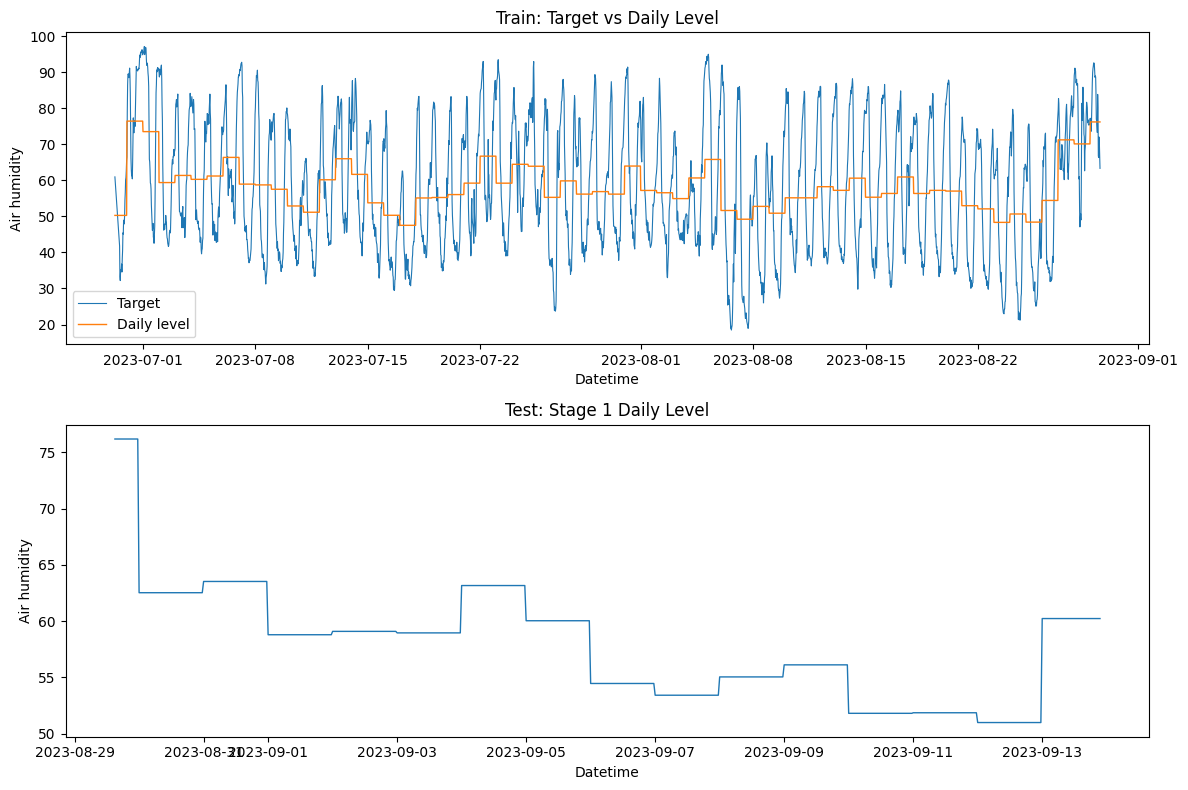

In [22]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8)
)

axes[0].plot(
    full.iloc[:N]["datetime"],
    train[TARGET],
    linewidth=0.8
)
axes[0].plot(
    full.iloc[:N]["datetime"],
    full.iloc[:N]["lvl"],
    linewidth=1.0
)
axes[0].set_title(
    "Train: Target vs Daily Level"
)
axes[0].legend(
    ["Target", "Daily level"]
)

axes[1].plot(
    test["datetime"],
    lvl_te,
    linewidth=1.0
)
axes[1].set_title(
    "Test: Stage 1 Daily Level"
)

for ax in axes:
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Air humidity")

plt.tight_layout()
plt.show()


### Interpretasi

Visual ini membantu membaca kembali alasan dekomposisi: Tahap 1 mengikuti perubahan level harian, sedangkan bentuk naik-turun di dalam hari diserahkan ke Tahap 2.


# 17. Tahap 2 — Model Deviasi Intrahari

---

### Metodologi

Tahap 2 memodelkan **deviation** terhadap level. Recipe memakai dua formulasi:

- **A:** `y - daily_mean`, sehingga target deviation berpusat di sekitar mean harian;
- **B:** `y - stage1_level`, sehingga model dapat mengoreksi level Tahap 1.

Masing-masing formulasi menggunakan ensemble XGBoost + LightGBM dan kemudian digabungan sesuai parameter final.

### EDA justification

Pola intraday 48 slot, variasi intra-hari, dan hubungan temperatur–humidity menunjukkan bahwa sinyal pada skala sub-harian perlu dipelajari secara terpisah dari level harian. Fitur lag hanya berasal dari sensor eksogen; target lag tidak digunakan.


In [23]:
def _fill_phys(lvl_map):
    fx = full.copy()

    fx["phys_dev"] = (
        lvl_map*fx["phys_ratio"]
        - lvl_map
    )

    for L in [1,2,3,6,12]:
        fx[f"phys_dev_l{L}"] = (
            fx.groupby("day")["phys_dev"]
            .shift(L)
        )

    return fx

XGB_S2 = dict(
    max_depth=7,
    eta=0.025,
    subsample=0.85,
    colsample_bytree=0.55,
    min_child_weight=4,
    reg_lambda=1.5,
    tree_method="hist",
    nthread=1
)

XGB_SEEDS_S2 = 8
LGB_SEEDS_S2 = 7

AB_WEIGHT = 0.70
TREE_XGB_W = 0.82
AMP_S2 = 1.03

def stage2_trees(
    feat,
    fx,
    tr_idx,
    te_idx,
    tgt,
    registry_prefix=None
):
    X = (
        fx[feat]
        .fillna(0.0)
        .values
    )

    Xt = X[tr_idx]
    Xe = X[te_idx]

    feature_names = list(feat)

    d = xgb.DMatrix(
        Xt,
        label=tgt,
        feature_names=feature_names
    )

    xgb_models = []

    px_list = []

    for s in range(
        XGB_SEEDS_S2
    ):
        model = xgb.train(
            dict(
                XGB_S2,
                seed=SEED+s
            ),
            d,
            800
        )
        xgb_models.append(model)

        px_list.append(
            model.predict(
                xgb.DMatrix(
                    Xe,
                    feature_names=feature_names
                )
            )
        )

    px = np.mean(
        px_list,
        axis=0
    )

    lgb_models = []
    pl_list = []

    for s in range(
        LGB_SEEDS_S2
    ):
        model = (
            lgb.LGBMRegressor(
                n_estimators=900,
                learning_rate=0.02,
                num_leaves=52,
                subsample=0.85,
                subsample_freq=1,
                colsample_bytree=0.5,
                reg_lambda=1.5,
                min_child_samples=12,
                random_state=SEED+s,
                n_jobs=1,
                deterministic=True,
                force_row_wise=True,
                verbosity=-1
            )
            .fit(
                Xt,
                tgt
            )
        )

        lgb_models.append(model)

        pl_list.append(
            model.predict(Xe)
        )

    pl = np.mean(
        pl_list,
        axis=0
    )

    if registry_prefix is not None:
        MODEL_REGISTRY[
            registry_prefix+"_xgb_models"
        ] = xgb_models
        MODEL_REGISTRY[
            registry_prefix+"_lgb_models"
        ] = lgb_models
        MODEL_REGISTRY[
            registry_prefix+"_features"
        ] = feature_names

    return dict(
        xgb=px,
        lgbm=pl,
        blend=(
            TREE_XGB_W*px
            + (1-TREE_XGB_W)*pl
        )
    )

def stage2(
    tr_idx,
    te_idx,
    lvl_map,
    registry_prefix=None
):
    fx = _fill_phys(
        lvl_map
    )

    tr_idx = list(tr_idx)

    yv = y[
        np.array(tr_idx)
    ]

    dmean_f = (
        fx.iloc[tr_idx]
        .groupby("day")[TARGET]
        .transform("mean")
        .to_numpy()
    )

    lvl_f = (
        lvl_map.to_numpy()[
            np.array(tr_idx)
        ]
    )

    A = stage2_trees(
        S2,
        fx,
        tr_idx,
        te_idx,
        yv-dmean_f,
        registry_prefix=(
            None
            if registry_prefix is None
            else registry_prefix+"_A"
        )
    )

    B = stage2_trees(
        S2B,
        fx,
        tr_idx,
        te_idx,
        yv-lvl_f,
        registry_prefix=(
            None
            if registry_prefix is None
            else registry_prefix+"_B"
        )
    )

    dev = (
        AMP_S2
        * (
            AB_WEIGHT*A["blend"]
            + (1-AB_WEIGHT)*B["blend"]
        )
    )

    return dict(
        A=A["blend"],
        B=B["blend"],
        dev=dev
    )

tri = list(
    range(N)
)

tei = list(
    range(
        N,
        N+len(test)
    )
)

S2P = stage2(
    tri,
    tei,
    full["lvl"],
    registry_prefix="final_stage2"
)

devA = S2P["A"]
devB = S2P["B"]
dev_te = S2P["dev"]

print(
    "Stage 2 A: mean %+.3f | std %.3f"
    % (
        devA.mean(),
        devA.std()
    )
)

print(
    "Stage 2 B: mean %+.3f | std %.3f"
    % (
        devB.mean(),
        devB.std()
    )
)

print(
    "Stage 2 deviation: mean %+.3f | std %.3f | range [%.3f, %.3f]"
    % (
        dev_te.mean(),
        dev_te.std(),
        dev_te.min(),
        dev_te.max()
    )
)


Stage 2 A: mean +0.497 | std 17.914
Stage 2 B: mean -0.587 | std 16.785
Stage 2 deviation: mean +0.177 | std 18.072 | range [-27.198, 30.107]


### Output dan interpretasi

`devA`, `devB`, dan `dev_te` adalah keluaran Tahap 2. Keduanya menangkap bentuk intraday yang kemudian direkonstruksi dengan level Tahap 1.


# 18. Direct Ensemble — Model Pembanding

---

### Metodologi

Direct ensemble memprediksi `air_humidity` secara langsung dari fitur row-level. Model ini dipertahankan hanya sebagai **pembanding metodologis**, bukan sebagai komponen final.

### EDA justification

EDA menunjukkan dua struktur yang berbeda—daily level dan intraday variation. Direct ensemble dipertahankan untuk menguji alternatif yang tidak melakukan dekomposisi pada setiap fold validasi. Dengan demikian, perbandingan tetap dapat dibaca sebagai pertanyaan: **apakah dekomposisi membantu memisahkan dua jenis variasi tersebut?**


In [24]:
def direct(
    tr_idx,
    te_idx,
    yv,
    registry_prefix=None
):
    X = (
        full[DIRECT_COLS]
        .fillna(0.0)
        .values
    )

    Xt = X[tr_idx]
    Xe = X[te_idx]

    d = xgb.DMatrix(
        Xt,
        label=yv,
        feature_names=list(DIRECT_COLS)
    )

    xgb_models = []
    px_list = []

    for s in range(4):
        model = xgb.train(
            dict(
                max_depth=5,
                eta=0.025,
                subsample=0.85,
                colsample_bytree=0.7,
                min_child_weight=5,
                reg_lambda=3,
                tree_method="hist",
                nthread=1,
                seed=SEED+s
            ),
            d,
            600
        )

        xgb_models.append(model)

        px_list.append(
            model.predict(
                xgb.DMatrix(
                    Xe,
                    feature_names=list(DIRECT_COLS)
                )
            )
        )

    px = np.mean(
        px_list,
        axis=0
    )

    lgb_models = []
    pl_list = []

    for s in range(4):
        model = (
            lgb.LGBMRegressor(
                n_estimators=650,
                learning_rate=0.025,
                num_leaves=31,
                subsample=0.85,
                subsample_freq=1,
                colsample_bytree=0.7,
                reg_lambda=3,
                min_child_samples=20,
                random_state=SEED+s,
                n_jobs=1,
                deterministic=True,
                force_row_wise=True,
                verbosity=-1
            )
            .fit(
                Xt,
                yv
            )
        )

        lgb_models.append(model)

        pl_list.append(
            model.predict(Xe)
        )

    pl = np.mean(
        pl_list,
        axis=0
    )

    sc = StandardScaler().fit(
        Xt
    )

    rr = (
        Ridge(alpha=5)
        .fit(
            sc.transform(Xt),
            yv
        )
        .predict(
            sc.transform(Xe)
        )
    )

    if registry_prefix is not None:
        MODEL_REGISTRY[
            registry_prefix+"_xgb_models"
        ] = xgb_models
        MODEL_REGISTRY[
            registry_prefix+"_lgb_models"
        ] = lgb_models
        MODEL_REGISTRY[
            registry_prefix+"_ridge"
        ] = sc
        MODEL_REGISTRY[
            registry_prefix+"_features"
        ] = list(DIRECT_COLS)

    return (
        0.45*px
        + 0.35*pl
        + 0.20*rr
    )

direct_te = direct(
    tri,
    tei,
    y,
    registry_prefix="final_direct"
)

print(
    "Direct ensemble test mean %.3f | std %.3f"
    % (
        direct_te.mean(),
        direct_te.std()
    )
)

print("Direct ensemble hanya digunakan sebagai model pembanding,")
print("bukan komponen final dekomposisi.")


Direct ensemble test mean 57.127 | std 16.692
Direct ensemble hanya digunakan sebagai model pembanding,
bukan komponen final dekomposisi.


### Interpretasi

Prediksi direct tidak digabungkan ke output final. Perannya terbatas sebagai benchmark yang membantu membaca pilihan metodologi secara transparan.


# 19. Validasi Silang Temporal dan Evaluasi RMSE

---

### Metodologi

Validasi menggunakan **rolling-origin / expanding-window** pada potongan waktu train. Strategi ini mensimulasikan pseudo-future: data masa depan setiap fold tidak boleh memengaruhi training fold.

Metrik resmi kompetisi adalah **RMSE**:

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

### EDA justification

Audit temporal menunjukkan data terurut dan didominasi interval 30 menit. Karena itu, validasi acak tidak merepresentasikan kondisi forecast secara tepat. Rolling-origin dipilih agar evaluasi mengikuti arah waktu.


In [25]:
def causal_ewm(x, a):
    x = np.asarray(
        x,
        float
    )
    return (
        pd.Series(x)
        .ewm(alpha=a)
        .mean()
        .to_numpy()
        if a < 1
        else x
    )

SMOOTH_ALPHA = 0.72

days = list(
    full.iloc[:N].day.unique()
)

FOLDS = [
    (
        days[:38],
        days[38:53]
    ),
    (
        days[:53],
        days[53:68]
    ),
    (
        days[:58],
        days[58:]
    )
]

rows = []

for tdays, vdays in FOLDS:

    tmask = (
        full["day"].isin(tdays)
        & (full.index < N)
    )

    vmask = (
        full["day"].isin(vdays)
        & (full.index < N)
    )

    ti = list(
        full.index[tmask]
    )

    vi = list(
        full.index[vmask]
    )

    vday = full.loc[
        vi,
        "day"
    ].to_numpy()

    lvl_f, lvl_f0, _, _ = stage1(
        tdays,
        tr_daymean.reindex(tdays),
        list(vdays)
    )

    baseC = (
        full["day"]
        .map(lvl_f)
        .to_numpy()[vmask.values]
    )

    base0 = (
        full["day"]
        .map(lvl_f0)
        .to_numpy()[vmask.values]
    )

    yv = y[
        vmasks := vmask.values[:N]
    ]

    P = stage2(
        ti,
        vi,
        full["day"].map(lvl_f)
    )

    dr = direct(
        ti,
        vi,
        y[
            tmask.values[:N]
        ]
    )

    R = lambda p: float(
        np.sqrt(
            np.mean(
                (
                    np.asarray(p)
                    - yv
                )**2
            )
        )
    )

    dm = lambda p: (
        pd.Series(p)
        .groupby(
            pd.Series(vday)
        )
        .transform("mean")
        .to_numpy()
    )

    tvm = dm(yv)

    rows.append(
        (
            str(
                vdays[0].date()
            ),
            float(
                np.sqrt(
                    np.mean(
                        (
                            dm(base0)
                            - tvm
                        )**2
                    )
                )
            ),
            float(
                np.sqrt(
                    np.mean(
                        (
                            dm(baseC)
                            - tvm
                        )**2
                    )
                )
            ),
            R(
                causal_ewm(
                    base0+P["dev"],
                    SMOOTH_ALPHA
                )
            ),
            R(
                causal_ewm(
                    baseC+P["dev"],
                    SMOOTH_ALPHA
                )
            ),
            R(dr)
        )
    )

    print(
        "Fold %s | daily base %.3f -> carry %.3f | "
        "recon base %.3f -> carry %.3f | direct %.3f"
        % rows[-1]
    )

mr = np.mean(
    [
        r[1:]
        for r in rows
    ],
    axis=0
)

print("-" * 78)
print(
    "CV mean | daily base %.3f -> carry %.3f | "
    "recon base %.3f -> carry %.3f | direct %.3f"
    % tuple(mr)
)
print("Interpretasi:")
print("- CV digunakan untuk membaca kestabilan metode pada potongan waktu train.")
print("- CV tidak mengakses target pada periode test.")


Fold 2023-08-06 | daily base 8.065 -> carry 8.011 | recon base 9.329 -> carry 9.285 | direct 9.244
Fold 2023-08-21 | daily base 6.975 -> carry 6.954 | recon base 8.876 -> carry 8.862 | direct 9.679
Fold 2023-08-26 | daily base 9.328 -> carry 9.391 | recon base 12.170 -> carry 12.221 | direct 13.322
------------------------------------------------------------------------------
CV mean | daily base 8.123 -> carry 8.119 | recon base 10.125 -> carry 10.123 | direct 10.748
Interpretasi:
- CV digunakan untuk membaca kestabilan metode pada potongan waktu train.
- CV tidak mengakses target pada periode test.


### Interpretasi

Angka RMSE yang muncul di cell di atas adalah hasil validasi pada **target train yang memang tersedia**. Tidak ada ground truth test yang digunakan. Hasil fold digunakan untuk transparansi kestabilan recipe, bukan untuk membuat klaim akurasi test.


# 20. Inferensi Akhir — Rekonstruksi Prediksi Internal

---

### Metodologi

Prediksi final model inti direkonstruksi sebagai:

`daily level + intraday deviation`, kemudian melalui causal EWM dan clipping 0–100 sesuai recipe sumber.

### EDA justification

Pemisahan level dan deviation berasal dari EDA daily/intraday. EWM digunakan sesuai recipe final yang sudah dibekukan; notebook finalization tidak mencari nilai alpha baru.


In [26]:
decomp = (
    lvl_te
    + dev_te
)

pred_internal = np.clip(
    causal_ewm(
        decomp,
        SMOOTH_ALPHA
    ),
    0.0,
    100.0
)

submission_internal = samp.copy()

submission_internal[TARGET] = np.round(
    pred_internal,
    4
)

submission_internal["datetime"] = (
    test["datetime"]
    .dt.strftime(
        "%Y-%m-%d %H:%M:%S"
    )
)

print("Prediksi internal akhir berhasil dibuat.")
print(
    "Shape:",
    submission_internal.shape
)
print(
    "Mean %.3f | std %.3f | min %.3f | max %.3f"
    % (
        pred_internal.mean(),
        pred_internal.std(),
        pred_internal.min(),
        pred_internal.max()
    )
)
print("Catatan: file ini hanya objek internal untuk dilanjutkan ke post-modelling.")
print("Tidak ada file submission lama yang dibaca sebagai input.")


Prediksi internal akhir berhasil dibuat.
Shape: (734, 2)
Mean 57.959 | std 18.600 | min 26.058 | max 91.021
Catatan: file ini hanya objek internal untuk dilanjutkan ke post-modelling.
Tidak ada file submission lama yang dibaca sebagai input.


### Output dan interpretasi

`pred_internal` adalah prediksi dari pipeline model inti sebelum post-modelling. Objek ini tetap berada di memori dan menjadi input untuk tahap berikutnya.


# 21. Pascapemodelan Tahap 1 — Kompresi Ekor

---

### Metodologi

Tahap ini menerapkan transformasi `kompresi ekor` dengan parameter yang sudah dibekukan dari recipe eksperimen sebelumnya. **Tidak ada pencarian parameter baru pada notebook finalization.**

### EDA justification

EDA target dan EDA outlier menunjukkan adanya ekor distribusi dan nilai ekstrem yang perlu **diaudit**. Namun, parameter transformasi tetap berasal dari recipe sumber, sehingga EDA di sini berfungsi menjelaskan tujuan transformasi, bukan memilih angka baru.


In [27]:
def clip100(v):
    return np.clip(
        np.asarray(v, dtype=float),
        0.0,
        100.0
    )

def tail_compression(
    v,
    quantile,
    strength
):
    v = np.asarray(
        v,
        dtype=float
    )

    center = float(
        np.median(v)
    )

    distance = np.abs(
        v-center
    )

    threshold = float(
        np.quantile(
            distance,
            quantile
        )
    )

    return (
        v
        - strength
        * np.sign(v-center)
        * np.maximum(
            distance-threshold,
            0.0
        )
    )

# Pemenang utama 20-idea search yang dibekukan:
# tail compression, quantile 0.85, strength 0.20.
post_1 = clip100(
    tail_compression(
        pred_internal,
        quantile=0.85,
        strength=0.20
    )
)

print("Pascapemodelan tahap 1 selesai.")


Pascapemodelan tahap 1 selesai.


### Output dan interpretasi

Tahap ini mengurangi ekstremitas prediksi secara terkontrol tanpa menggunakan ground truth test.


# 22. Pascapemodelan Tahap 2 — Resep Berlapis yang Dibekukan

---

### Metodologi

Urutan transformasi dipertahankan: affine shift → pemusatan lead/lag → median bergerak → kompresi ekor → gabungan.

### EDA justification

Tahap ini berkaitan dengan pemeriksaan kontinuitas temporal dan distribusi prediksi. Parameter dan urutan berasal dari recipe final yang sudah dipilih sebelumnya; notebook tidak melakukan retuning.


In [28]:
def lead_lag_center(
    v,
    weight
):
    v = np.asarray(
        v,
        dtype=float
    )

    prev = np.roll(
        v,
        1
    )
    prev[0] = v[0]

    nxt = np.roll(
        v,
        -1
    )
    nxt[-1] = v[-1]

    center = (
        0.5*prev
        + 0.5*nxt
    )

    return (
        (1-weight)*v
        + weight*center
    )

def rolling_median_blend(
    v,
    window,
    weight
):
    v = np.asarray(
        v,
        dtype=float
    )

    med = (
        pd.Series(v)
        .rolling(
            window,
            center=True,
            min_periods=1
        )
        .median()
        .to_numpy()
    )

    return (
        (1-weight)*v
        + weight*med
    )

ml1 = clip100(
    post_1 - 0.40
)

ml2 = clip100(
    lead_lag_center(
        ml1,
        weight=0.275
    )
)

ml3 = clip100(
    rolling_median_blend(
        ml2,
        window=7,
        weight=0.20
    )
)

ml4 = clip100(
    tail_compression(
        ml3,
        quantile=0.85,
        strength=0.20
    )
)

post_2 = clip100(
    0.20*ml3
    + 0.80*ml4
)

print("Pascapemodelan tahap 2 selesai.")
print("Post-2 mean %.3f | std %.3f" % (
    post_2.mean(),
    post_2.std()
))


Pascapemodelan tahap 2 selesai.
Post-2 mean 57.731 | std 18.189


### Output dan interpretasi

Tahap ini berfokus pada stabilisasi bentuk prediksi temporal tanpa mengakses target test.


# 23. Pascapemodelan Tahap 3 — Resep Beam yang Dibekukan

---

### Metodologi

Beam recipe mempertahankan amplitudo scaling, kelengkungan adjustment, median bergerak, slot gabungan, dan EWM akhir dengan parameter yang sudah dibekukan.

### EDA justification

EDA intraday digunakan untuk menjelaskan mengapa struktur berbasis slot waktu dan continuity layak diperiksa. Nilai parameter tidak dipilih ulang di notebook ini.


In [29]:
def curvature(
    v,
    strength
):
    v = np.asarray(
        v,
        dtype=float
    )

    d1 = np.diff(
        v,
        prepend=v[0]
    )

    d2 = np.diff(
        d1,
        prepend=d1[0]
    )

    return (
        v
        + strength*d2
    )

def slot_blend(
    v,
    timestamps,
    weight
):
    v = np.asarray(
        v,
        dtype=float
    )

    t = pd.Series(
        pd.to_datetime(
            timestamps
        )
    ).reset_index(drop=True)

    slot = (
        t.dt.hour.to_numpy()*2
        + t.dt.minute.to_numpy()//30
    )

    tmp = pd.DataFrame({
        "slot": slot,
        "value": v
    })

    slot_mean = (
        tmp.groupby("slot")["value"]
        .transform("mean")
        .to_numpy()
    )

    return (
        (1-weight)*v
        + weight*slot_mean
    )

beam1 = clip100(
    np.median(post_2)
    + 1.02*(
        post_2
        - np.median(post_2)
    )
)

beam2 = clip100(
    curvature(
        beam1,
        strength=-0.10
    )
)

beam3 = clip100(
    rolling_median_blend(
        beam2,
        window=7,
        weight=0.10
    )
)

beam4 = clip100(
    slot_blend(
        beam3,
        test["datetime"],
        weight=0.05
    )
)

ewm_final = causal_ewm(
    beam4,
    0.95
)

final_prediction = clip100(
    0.97*beam4
    + 0.03*ewm_final
)

print("Pascapemodelan tahap 3 / Beam selesai.")
print(
    "Final mean %.3f | std %.3f | min %.3f | max %.3f"
    % (
        final_prediction.mean(),
        final_prediction.std(),
        final_prediction.min(),
        final_prediction.max()
    )
)


Pascapemodelan tahap 3 / Beam selesai.
Final mean 57.675 | std 18.465 | min 28.264 | max 88.874


### Output dan interpretasi

Tahap akhir memperhalus amplitudo dan bentuk temporal sambil mempertahankan batas fisik 0–100.


# 24. Visualisasi Model Akhir dan Pascapemodelan

---

### Mengapa visualisasi ini dilakukan

Visualisasi digunakan untuk membandingkan bentuk output dari model inti hingga post-modelling. Tidak ada target test yang digunakan untuk menilai visual ini.


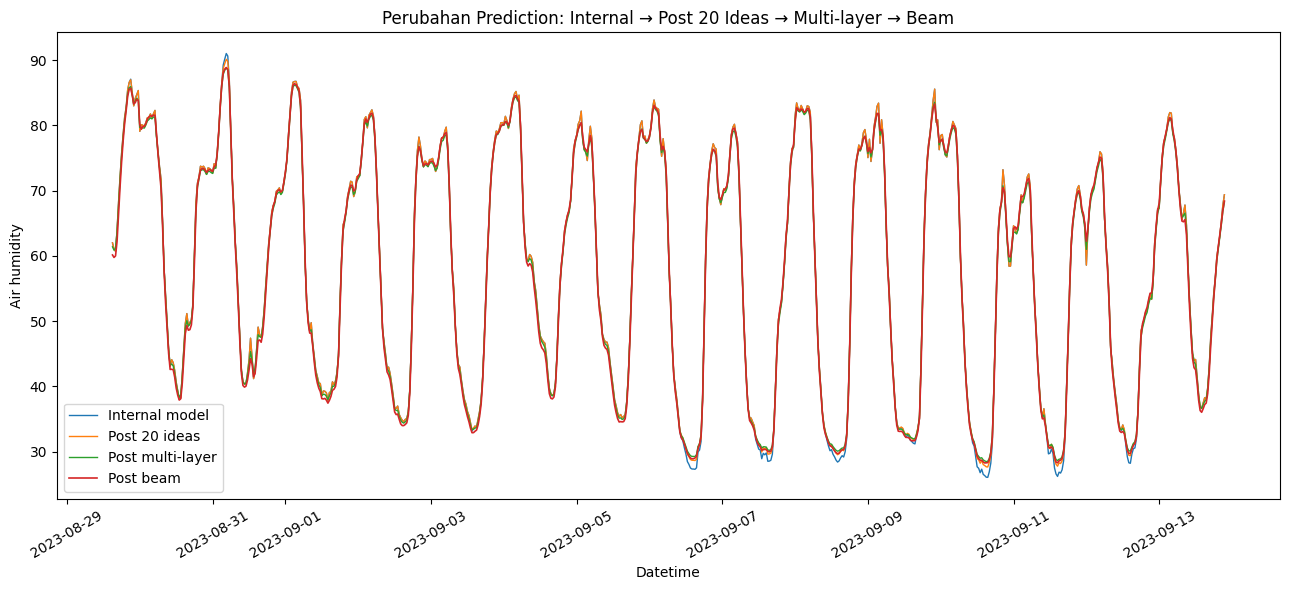

Visualisasi menampilkan perubahan bentuk prediction sepanjang pipeline.


In [30]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)

ax.plot(
    test["datetime"],
    pred_internal,
    linewidth=1.0
)

ax.plot(
    test["datetime"],
    post_1,
    linewidth=1.0
)

ax.plot(
    test["datetime"],
    post_2,
    linewidth=1.0
)

ax.plot(
    test["datetime"],
    final_prediction,
    linewidth=1.2
)

ax.set_title(
    "Perubahan Prediction: Internal → Post 20 Ideas → Multi-layer → Beam"
)
ax.set_xlabel("Datetime")
ax.set_ylabel("Air humidity")
ax.legend(
    [
        "Internal model",
        "Post 20 ideas",
        "Post multi-layer",
        "Post beam"
    ]
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Visualisasi menampilkan perubahan bentuk prediction sepanjang pipeline.")


### Interpretasi

Visual ini seharusnya dibaca sebagai pemeriksaan **bentuk dan kontinuitas**, bukan sebagai ukuran akurasi. Kenaikan atau penurunan kurva tidak boleh diterjemahkan sebagai keberhasilan prediksi test tanpa ground truth.


# 25. Pemeriksaan Kepentingan Fitur

---

### Metodologi

Feature importance digunakan sebagai diagnostik setelah model terbentuk untuk melihat fitur yang dominan pada model tree. Ini merupakan **post-hoc diagnostic**, bukan alasan untuk menghapus atau menambah feature pada recipe final.


,fitur,importance
15,co2_dm,130
7,air_temperature_dm,129
17,co2_dmin,100
5,ontario_units,68
2,daily_max_above_Tbase,67
19,pressure_dm,56
37,soil_humidity_line1_dmin,55
12,es_dsd,54
8,air_temperature_dsd,51
44,soil_humidity_line3_dsd,43


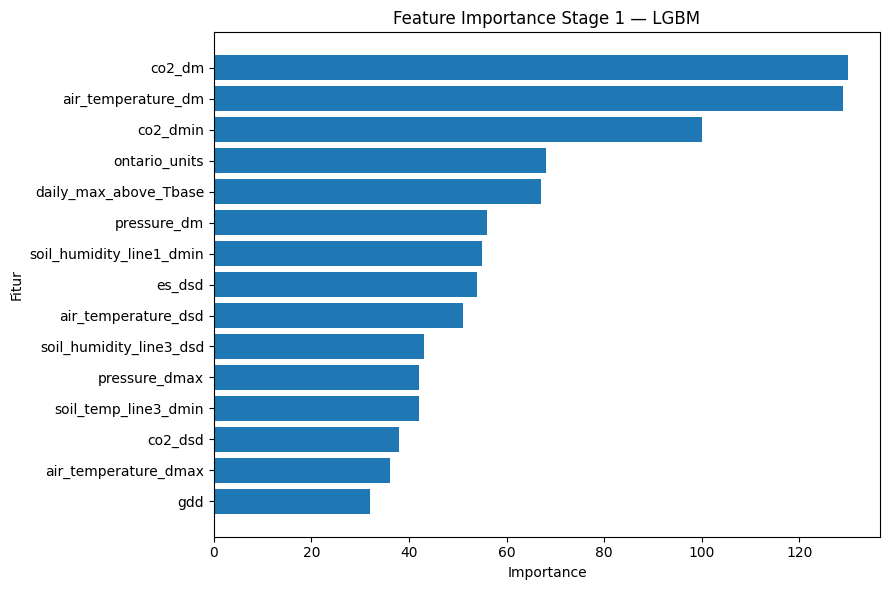

,fitur,importance
18,air_temperature_dsd,2279
19,es_dsd,2150
9,pressure_dev,1776
13,soil_humidity_line1_dev,1584
8,co2_dev,1500
15,soil_humidity_line3_dev,1370
10,soil_temp_line1_dev,1352
16,soil_ec_line2_dev,1337
12,soil_temp_line3_dev,1275
11,soil_temp_line2_dev,1235


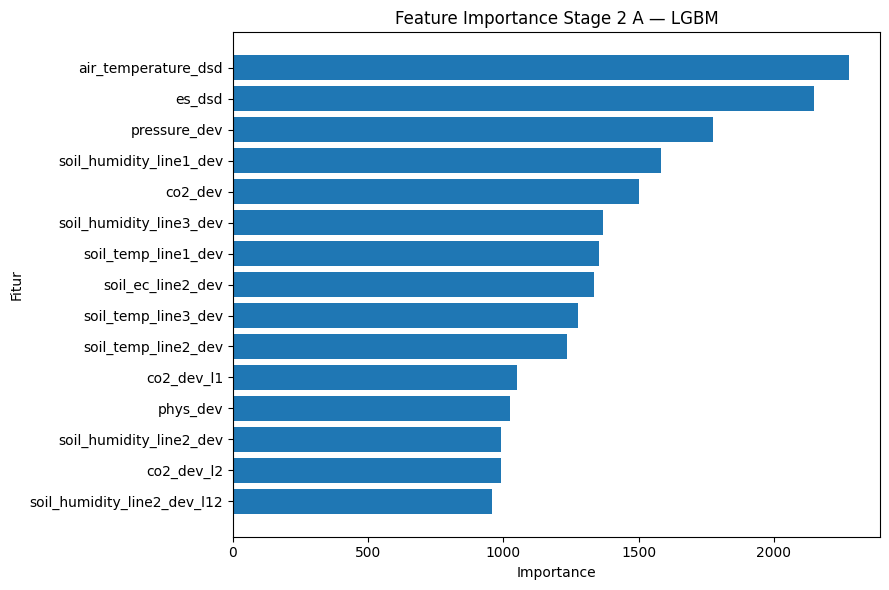

,fitur,importance
9,pressure_dev,1247
8,co2_dev,1227
75,pressure_dm,1136
71,gdd,1134
70,ontario_units,1080
74,co2_dm,1022
12,soil_temp_line3_dev,992
18,air_temperature_dsd,963
68,daily_max_reduction,952
10,soil_temp_line1_dev,915


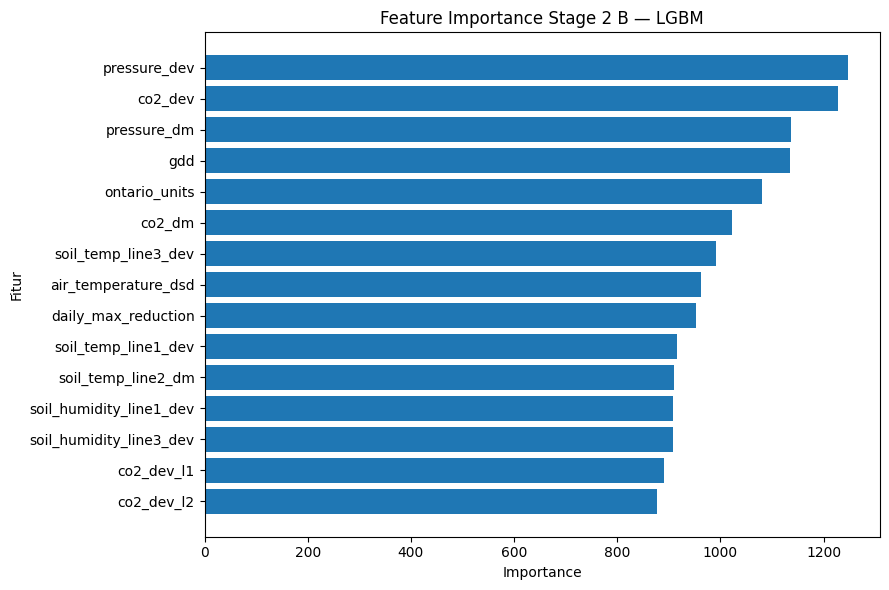

Feature importance ditampilkan sebagai diagnostik post-hoc.


In [31]:
def show_lgb_importance(
    model,
    features,
    title,
    top_n=15
):
    imp = pd.DataFrame({
        "fitur": features,
        "importance": model.feature_importances_
    }).sort_values(
        "importance",
        ascending=False
    ).head(top_n)

    display(imp)

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    ax.barh(
        imp["fitur"][::-1],
        imp["importance"][::-1]
    )

    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.set_ylabel("Fitur")

    plt.tight_layout()
    plt.show()

if (
    "final_stage1_lgbm" in MODEL_REGISTRY
):
    show_lgb_importance(
        MODEL_REGISTRY["final_stage1_lgbm"],
        MODEL_REGISTRY["final_stage1_features"],
        "Feature Importance Stage 1 — LGBM"
    )

if (
    "final_stage2_A_lgb_models"
    in MODEL_REGISTRY
):
    final_A_lgb = MODEL_REGISTRY[
        "final_stage2_A_lgb_models"
    ][0]

    show_lgb_importance(
        final_A_lgb,
        MODEL_REGISTRY[
            "final_stage2_A_features"
        ],
        "Feature Importance Stage 2 A — LGBM"
    )

if (
    "final_stage2_B_lgb_models"
    in MODEL_REGISTRY
):
    final_B_lgb = MODEL_REGISTRY[
        "final_stage2_B_lgb_models"
    ][0]

    show_lgb_importance(
        final_B_lgb,
        MODEL_REGISTRY[
            "final_stage2_B_features"
        ],
        "Feature Importance Stage 2 B — LGBM"
    )

print("Feature importance ditampilkan sebagai diagnostik post-hoc.")


### Interpretasi

Feature importance membantu menjelaskan kontribusi relatif fitur di model tree. Nilai ini tidak boleh disamakan dengan kausalitas dan tidak digunakan untuk mengubah feature list final pada notebook ini.


# 26. Analisis Pascapemodelan — Pemeriksaan Prediksi Tanpa Ground Truth Test

---

Bagian ini dilakukan **setelah final prediksi**. Tujuannya memeriksa karakteristik output model tanpa mengklaim akurasi test.


Statistik prediction final:


,prediction
count,734.000000
mean,57.674967
std,18.477554
min,28.264153
1%,28.673202
5%,30.284394
25%,39.390495
50%,59.980696
75%,75.234291
95%,82.416908


Missing prediction: 0
Infinite prediction: 0
Di luar 0–100: 0


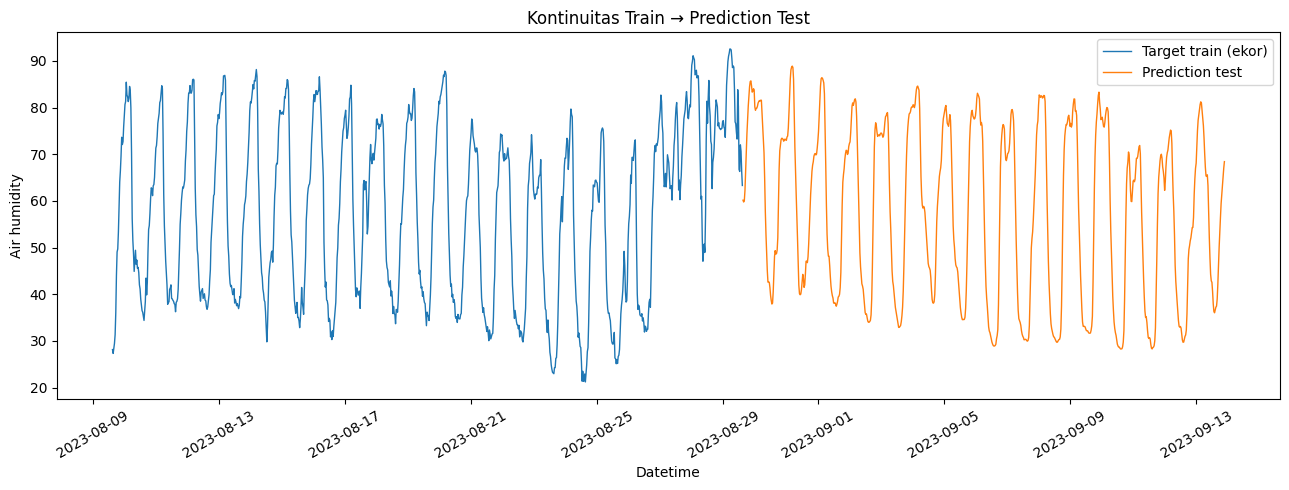

,mean,std,min,max
slot,,,,
0,73.829474,5.777930,62.245396,80.479396
1,74.807976,5.579922,64.101841,82.696686
2,75.677425,5.307152,64.100797,82.482737
3,76.537020,5.175264,64.640882,83.055512
4,77.680594,4.912131,66.970059,84.576063
5,78.828068,4.729556,69.093361,86.179222
6,79.700498,4.737268,69.090819,86.391421
7,80.061515,4.724853,69.499815,88.078477
8,80.075980,4.539168,70.613080,88.639372


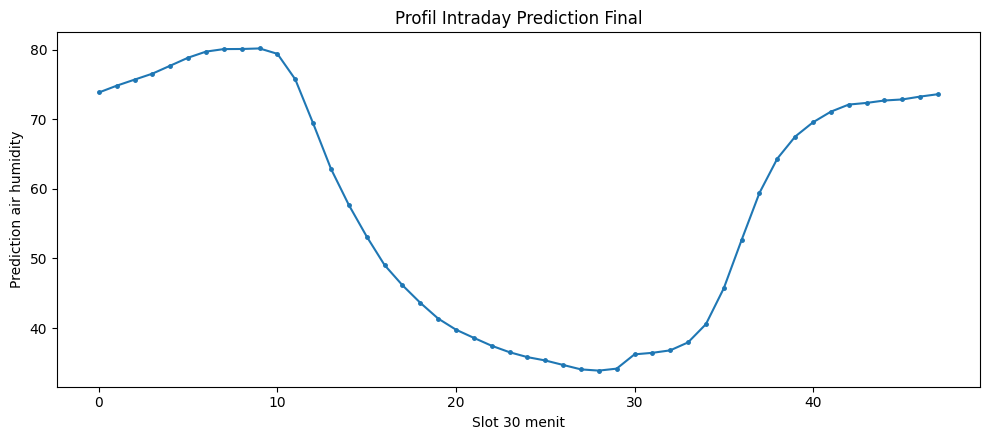

,train_target,prediction_test
mean,58.185728,57.674967
std,17.997686,18.477554
min,18.470000,28.264153
max,97.090000,88.873746


In [32]:
pred_series = pd.Series(final_prediction, name=TARGET)

print("Statistik prediction final:")
pred_stats = pred_series.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
display(pred_stats.to_frame("prediction"))

print("Missing prediction:", int(pred_series.isna().sum()))
print("Infinite prediction:", int(np.isinf(pred_series.to_numpy(float)).sum()))
print("Di luar 0–100:", int(((pred_series < 0) | (pred_series > 100)).sum()))

# Sambungan train → test secara visual, bukan evaluasi akurasi.
train_tail_n = min(20 * 48, len(train))
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train[KEY].iloc[-train_tail_n:], train[TARGET].iloc[-train_tail_n:], linewidth=1.0, label="Target train (ekor)")
ax.plot(test[KEY], final_prediction, linewidth=1.0, label="Prediction test")
ax.set_title("Kontinuitas Train → Prediction Test")
ax.set_xlabel("Datetime")
ax.set_ylabel("Air humidity")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Variasi prediksi antar slot waktu.
pred_df = pd.DataFrame({"datetime": test[KEY], TARGET: final_prediction})
pred_df["slot"] = pred_df["datetime"].dt.hour * 2 + pred_df["datetime"].dt.minute // 30
slot_pred = pred_df.groupby("slot")[TARGET].agg(["mean", "std", "min", "max"])
display(slot_pred)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(slot_pred.index, slot_pred["mean"], marker="o", markersize=2.5)
ax.set_title("Profil Intraday Prediction Final")
ax.set_xlabel("Slot 30 menit")
ax.set_ylabel("Prediction air humidity")
plt.tight_layout()
plt.show()

train_stats = train[TARGET].describe()[["mean", "std", "min", "max"]]
pred_compare = pd.DataFrame({"train_target": train_stats, "prediction_test": pred_series.describe()[["mean", "std", "min", "max"]]})
display(pred_compare)


### Interpretasi

Pemeriksaan ini hanya membaca bentuk prediksi: sebaran, batas fisik, missing/infinity, sambungan temporal, variasi intraday, dan perbandingan statistik deskriptif terhadap train. Tidak ada pernyataan “akurasi test” karena ground truth test tidak tersedia.


# 27. Artefak Model — `.pth`

---

### Tujuan

Guidebook mensyaratkan notebook dan model prediksi dikumpulkan serta meminta seed, reproducibility, dan dokumentasi tahapan. Artefak berikut menyimpan **model yang benar-benar digunakan oleh pipeline final** dengan metadata dan representasi native model, tanpa mengubah recipe prediksi.

Artefak final mencakup Tahap 1 dan Tahap 2 A/B. Direct ensemble tidak dimasukkan karena hanya berfungsi sebagai pembanding.


In [33]:
MODEL_ARTIFACT_PATH = Path("HBD_AirHumidity_Final_Model.pth")


def ridge_to_artifact(model, scaler, features):
    return {
        "coef": np.asarray(model.coef_, dtype=float),
        "intercept": float(np.asarray(model.intercept_).reshape(-1)[0]) if np.asarray(model.intercept_).ndim else float(model.intercept_),
        "scaler_mean": np.asarray(scaler.mean_, dtype=float),
        "scaler_scale": np.asarray(scaler.scale_, dtype=float),
        "features": list(features),
        "alpha": float(model.alpha),
    }


def lgb_to_artifact(model):
    return {
        "model_string": model.booster_.model_to_string(),
        "n_features": int(model.n_features_in_),
    }


def xgb_to_artifact(model):
    return {
        "raw_model": model.save_raw(),
    }


final_stage1_ridge = MODEL_REGISTRY["final_stage1_ridge"]
final_stage1_scaler = MODEL_REGISTRY["final_stage1_ridge_scaler"]
final_stage1_lgb = MODEL_REGISTRY["final_stage1_lgbm"]
final_stage1_xgb = MODEL_REGISTRY["final_stage1_xgb"]

final_A_xgb = MODEL_REGISTRY["final_stage2_A_xgb_models"]
final_A_lgb = MODEL_REGISTRY["final_stage2_A_lgb_models"]
final_B_xgb = MODEL_REGISTRY["final_stage2_B_xgb_models"]
final_B_lgb = MODEL_REGISTRY["final_stage2_B_lgb_models"]

artifact = {
    "artifact_version": 1,
    "target": TARGET,
    "datetime_key": KEY,
    "model_family": "dekomposisi dua tahap",
    "seed": int(SEED),
    "stage1": {
        "ridge": ridge_to_artifact(final_stage1_ridge, final_stage1_scaler, MODEL_REGISTRY["final_stage1_features"]),
        "lgbm": lgb_to_artifact(final_stage1_lgb),
        "xgb": xgb_to_artifact(final_stage1_xgb),
        "blend": {"ridge": 0.40, "lgbm": 0.35, "xgb": 0.25},
        "carry": {"rho": CARRY_RHO, "weight": CARRY_W, "last_n": CARRY_NLAST},
    },
    "stage2": {
        "A": {
            "features": list(MODEL_REGISTRY["final_stage2_A_features"]),
            "xgb": [xgb_to_artifact(m) for m in final_A_xgb],
            "lgbm": [lgb_to_artifact(m) for m in final_A_lgb],
            "tree_blend_weight_xgb": TREE_XGB_W,
        },
        "B": {
            "features": list(MODEL_REGISTRY["final_stage2_B_features"]),
            "xgb": [xgb_to_artifact(m) for m in final_B_xgb],
            "lgbm": [lgb_to_artifact(m) for m in final_B_lgb],
            "tree_blend_weight_xgb": TREE_XGB_W,
        },
        "A_B_blend_weight_A": AB_WEIGHT,
        "amplitude": AMP_S2,
    },
    "feature_engineering": {
        "DRIV": list(DRIV),
        "DAG": list(DAG),
        "HARM": list(HARM),
        "S2": list(S2),
        "S2B": list(S2B),
    },
    "reconstruction": {
        "smoothing_alpha": SMOOTH_ALPHA,
        "physical_clip": [0.0, 100.0],
    },
    "post_modelling": {
        "tail_quantile": 0.85,
        "tail_strength": 0.20,
        "affine_shift": -0.40,
        "lead_lag_weight": 0.275,
        "rolling_window": 7,
        "rolling_weight_stage2": 0.20,
        "rolling_weight_beam": 0.10,
        "beam_amplitude": 1.02,
        "curvature_strength": -0.10,
        "slot_blend_weight": 0.05,
        "beam_ewm_alpha": 0.95,
        "beam_ewm_weight": 0.03,
    },
}

# Simpan artefak; tidak menulis file model lain.
torch.save(artifact, MODEL_ARTIFACT_PATH)

artifact_size_mb = MODEL_ARTIFACT_PATH.stat().st_size / (1024 ** 2)
print("Artefak model berhasil disimpan.")
print("Lokasi :", MODEL_ARTIFACT_PATH)
print("Ukuran : %.2f MB" % artifact_size_mb)
print("Tipe   : metadata + representasi model asli")
print("Stage 1 feature:", len(artifact["stage1"]["ridge"]["features"]))
print("Stage 2 A/B feature:", len(artifact["stage2"]["A"]["features"]), "/", len(artifact["stage2"]["B"]["features"]))

# Sanity check load kembali.
try:
    loaded_artifact = torch.load(MODEL_ARTIFACT_PATH, map_location="cpu", weights_only=False)
except TypeError:
    loaded_artifact = torch.load(MODEL_ARTIFACT_PATH, map_location="cpu")

required_artifact_keys = {"artifact_version", "target", "stage1", "stage2", "feature_engineering", "reconstruction", "post_modelling"}
assert required_artifact_keys.issubset(loaded_artifact.keys())
assert loaded_artifact["target"] == TARGET
assert len(loaded_artifact["stage2"]["A"]["xgb"]) == XGB_SEEDS_S2
assert len(loaded_artifact["stage2"]["A"]["lgbm"]) == LGB_SEEDS_S2
print("Sanity check load artefak: PASS")


Artefak model berhasil disimpan.
Lokasi : HBD_AirHumidity_Final_Model.pth
Ukuran : 135.77 MB
Tipe   : metadata + representasi model asli
Stage 1 feature: 52
Stage 2 A/B feature: 65 / 78
Sanity check load artefak: PASS


### Interpretasi

`.pth` menyimpan metadata recipe, urutan feature, bobot gabungan, parameter dibekukan, dan representasi native model yang dipakai. Preprocessing yang diperlukan tetap didefinisikan oleh cell rekayasa fitur di notebook ini. Tidak ada model pretrained atau model dari sumber eksternal.


# 28. Submission Akhir Internal dan Output Resmi

---

### Metodologi

`final_submission` dibuat langsung dari `sample_submission` dan `final_prediksi`. File yang ditulis ke disk hanya **satu output final**, bukan kumpulan submission eksperimen.


In [34]:
FINAL_OUTPUT = Path("FINALIZATION_submission.csv")

final_submission = samp.copy()

final_submission[TARGET] = np.round(
    final_prediction,
    4
)

final_submission["datetime"] = (
    test["datetime"]
    .dt.strftime(
        "%Y-%m-%d %H:%M:%S"
    )
)

assert list(
    final_submission.columns
) == [
    KEY,
    TARGET
]

assert len(final_submission) == len(test)

assert (
    final_submission[KEY].tolist()
    == test[KEY].dt.strftime(
        "%Y-%m-%d %H:%M:%S"
    ).tolist()
)

assert final_submission[TARGET].notna().all()

assert np.isfinite(
    final_submission[TARGET]
    .to_numpy(float)
).all()

assert (
    (
        final_submission[TARGET]
        >= 0
    )
    & (
        final_submission[TARGET]
        <= 100
    )
).all()

final_submission.to_csv(
    FINAL_OUTPUT,
    index=False
)

print("FINALIZATION IPYNB — OUTPUT AKHIR SELESAI")
print("Output:", FINAL_OUTPUT)
print("Shape :", final_submission.shape)
print("Output akhir memiliki format:")
print("datetime, air_humidity")
print("Tidak ada GT/reference yang dibaca oleh notebook ini.")


FINALIZATION IPYNB — OUTPUT AKHIR SELESAI
Output: FINALIZATION_submission.csv
Shape : (734, 2)
Output akhir memiliki format:
datetime, air_humidity
Tidak ada GT/reference yang dibaca oleh notebook ini.


### Output dan interpretasi

Output final memiliki dua kolom:

```text
datetime,air_humidity
```

`final_submission` tetap menjadi DataFrame internal yang dapat diteruskan atau diunggah ke Kaggle. Notebook tidak pernah membaca kembali output ini sebagai input model.


# 29. Final QA — Integritas Output, Leakage, dan Artefak

---

QA dilakukan pada hasil akhir untuk memastikan pipeline menghasilkan output yang konsisten dengan schema kompetisi dan tidak bergantung pada data terlarang.


In [35]:
print("FINAL QA")
print("=" * 78)

# Input resmi.
assert TRAIN_PATH == Path("train.csv")
assert TEST_PATH == Path("test.csv")
assert SAMPLE_PATH == Path("sample_submission.csv")
assert TRAIN_PATH.exists() and TEST_PATH.exists() and SAMPLE_PATH.exists()

# Target dan sample.
assert TARGET in train.columns
assert TARGET not in test.columns
assert train[TARGET].notna().all()
assert list(samp.columns) == [KEY, TARGET]
assert pd.to_datetime(samp[KEY]).reset_index(drop=True).equals(test[KEY].reset_index(drop=True))

# Prediction dan schema.
assert len(final_prediction) == len(test)
assert np.isfinite(final_prediction).all()
assert ((final_prediction >= 0.0) & (final_prediction <= 100.0)).all()
assert list(final_submission.columns) == [KEY, TARGET]
assert len(final_submission) == len(test)
assert final_submission[KEY].tolist() == test[KEY].dt.strftime("%Y-%m-%d %H:%M:%S").tolist()
assert final_submission[TARGET].notna().all()
assert np.isfinite(final_submission[TARGET].to_numpy(float)).all()
assert ((final_submission[TARGET] >= 0) & (final_submission[TARGET] <= 100)).all()
assert final_submission[KEY].duplicated().sum() == 0

# Artefak.
assert MODEL_ARTIFACT_PATH.exists()
assert MODEL_ARTIFACT_PATH.stat().st_size > 0
assert required_artifact_keys.issubset(loaded_artifact.keys())

print("Input resmi tersedia             : LULUS")
print("Target test tidak digunakan      : LULUS")
print("Kecocokan sample dan test        : LULUS")
print("Jumlah prediction = test         : LULUS")
print("NaN / inf prediction             : LULUS")
print("Rentang prediction 0–100         : LULUS")
print("Schema final_submission           : LULUS")
print("Duplicate datetime final         : LULUS")
print("Artefak .pth tersedia + load     : LULUS")


FINAL QA
Input resmi tersedia             : LULUS
Target test tidak digunakan      : LULUS
Kecocokan sample dan test        : LULUS
Jumlah prediction = test         : LULUS
NaN / inf prediction             : LULUS
Rentang prediction 0–100         : LULUS
Schema final_submission           : LULUS
Duplicate datetime final         : LULUS
Artefak .pth tersedia + load     : LULUS


# 32. Kesimpulan Akhir

---

Pipeline final menggunakan pendekatan **dekomposisi dua tahap** yang dibenarkan oleh EDA: Tahap 1 menangani perubahan level harian, sedangkan Tahap 2 menangani variasi intraday. Validasi mengikuti urutan waktu, target lag dilarang untuk inference, dan post-modelling diperlakukan sebagai dibekukan recipe.

Tidak ada ground truth test yang digunakan di notebook. Dengan demikian, post-modelling dan sanity check pada test dibaca sebagai pemeriksaan karakteristik prediksi, bukan sebagai bukti akurasi.


<div align="center">
<h3>Ringkasan Finalization</h3>

<p><strong>Input resmi:</strong> train.csv · test.csv · sample_submission.csv</p>
<p><strong>Output final:</strong> FINALIZATION_submission.csv</p>
<p><strong>Artefak model:</strong> HBD_AirHumidity_Final_Model.pth</p>
<p><strong>Target:</strong> air_humidity · <strong>Metrik:</strong> RMSE · <strong>Seed:</strong> 42</p>
<p><strong>Prinsip:</strong> EDA-driven · Temporal validation · Leakage prevention · No external data</p>

<hr width="55%">
<h2>Terima Kasih</h2>
<p><strong>TEAM HBD</strong></p>
</div>
